# 📊 Análise Estatística — Zika Vírus (SINAN 2018–2026)

**Disciplina**: Banco de Dados / Modelagem Estatística  
**Dataset**: `ZIKA_BR_2018_2026_UNIFICADO.csv` — 236.398 notificações  
**Fonte**: SINAN — Sistema de Informação de Agravos de Notificação (DataSUS/MS)  

---

### Entregas deste notebook:
1. **Sazonalidade** — Decomposição da série temporal e identificação de padrões cíclicos
2. **Tendência por UF** — Evolução temporal dos casos confirmados por estado
3. **Previsão de Casos (Prophet)** — Modelagem preditiva com validação cruzada
4. **Agrupamento de Municípios (K-Means)** — Clustering por perfil epidemiológico

---
## ⚙️ Etapa 0 — Setup e Conexão com o Banco

Configuração de bibliotecas, conexão com PostgreSQL (NeonDB) e helpers.

In [99]:
# ── Instalação de dependências (executar apenas 1 vez) ──
# !pip install prophet statsmodels scikit-learn sqlalchemy psycopg2-binary python-dotenv seaborn matplotlib pandas

In [100]:
# ── Imports ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
from datetime import datetime
from urllib.parse import quote_plus

# Conexão com o banco
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

warnings.filterwarnings('ignore')

# ── Conexão ──
load_dotenv()

# Usa DATABASE_URL se estiver definida; caso contrário, monta a string
# de conexão a partir das variáveis PG* separadas do .env (NeonDB).
DATABASE_URL = os.getenv('DATABASE_URL')
if not DATABASE_URL:
    DATABASE_URL = (
        f"postgresql+psycopg2://"
        f"{quote_plus(os.getenv('PGUSER'))}:{quote_plus(os.getenv('PGPASSWORD'))}"
        f"@{os.getenv('PGHOST')}/{os.getenv('PGDATABASE')}"
        f"?sslmode={os.getenv('PGSSLMODE', 'require')}"
    )

engine = create_engine(DATABASE_URL)

def query_df(sql):
    """Executa SQL e retorna DataFrame."""
    return pd.read_sql(sql, engine)

print('✅ Conexão configurada com sucesso.')

✅ Conexão configurada com sucesso.


In [101]:
# ── Estilo global dos gráficos ──
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 10,
    'figure.dpi': 150
})
sns.set_style('whitegrid')

# Paleta personalizada para o projeto
COR_PRINCIPAL  = '#E63946'  # vermelho epidemiológico
COR_SECUNDARIA = '#457B9D'  # azul complementar
COR_DESTAQUE   = '#F4A261'  # laranja para destaques
PALETA_UFS     = sns.color_palette('tab10', 10)

print('✅ Estilo de gráficos configurado.')

✅ Estilo de gráficos configurado.


---
## 📈 Etapa 1 — Análise de Sazonalidade

Objetivo: identificar padrões cíclicos (sazonais) na incidência de Zika,
 utilizando a `vw_serie_temporal_semanal` que agrega casos por semana epidemiológica.

**Hipótese epidemiológica**: espera-se pico de casos entre dezembro e março
 (verão + período chuvoso → proliferação do Aedes aegypti).

### 1.1 — Extração e preparação dos dados

In [102]:
# ── Query na view (filtrando já na origem para 2018-2026) ──
# A view deriva ano/semana de dt_sin_pri. O filtro remove datas corrompidas
# do SINAN (ex.: registros com ano 1937) que poluiriam TODAS as análises.
df_semanal = query_df("""
    SELECT * FROM vw_serie_temporal_semanal
    WHERE nu_ano BETWEEN 2018 AND 2026
    ORDER BY nu_ano, sem_pri;
""")

print(f'Registros carregados: {len(df_semanal)}')
print(f'Colunas: {list(df_semanal.columns)}')
print(f'Período (ano): {df_semanal["nu_ano"].min()} a {df_semanal["nu_ano"].max()}')
df_semanal.head(10)

Registros carregados: 434
Colunas: ['nu_ano', 'sem_pri', 'total_casos', 'casos_confirmados']
Período (ano): 2018 a 2026


,nu_ano,sem_pri,total_casos,casos_confirmados
0,2018,1,381,79
1,2018,2,432,64
2,2018,3,470,93
3,2018,4,446,81
4,2018,5,477,89
5,2018,6,466,104
6,2018,7,477,117
7,2018,8,551,150
8,2018,9,537,152
9,2018,10,637,182


In [103]:
# ── Converter ano + semana ISO → data real (segunda-feira da semana) ──
def semana_para_data(row):
    try:
        return datetime.fromisocalendar(int(row['nu_ano']), int(row['sem_pri']), 1)
    except (ValueError, TypeError):
        return pd.NaT

df_semanal['ds'] = pd.to_datetime(df_semanal.apply(semana_para_data, axis=1))
df_semanal = df_semanal.dropna(subset=['ds']).sort_values('ds').reset_index(drop=True)

print(f'Registros após conversão: {len(df_semanal)}')
print(f'Intervalo: {df_semanal["ds"].min().date()} → {df_semanal["ds"].max().date()}')

Registros após conversão: 434
Intervalo: 2018-01-01 → 2026-04-20


### 1.2 — Série temporal completa (notificações × confirmados)

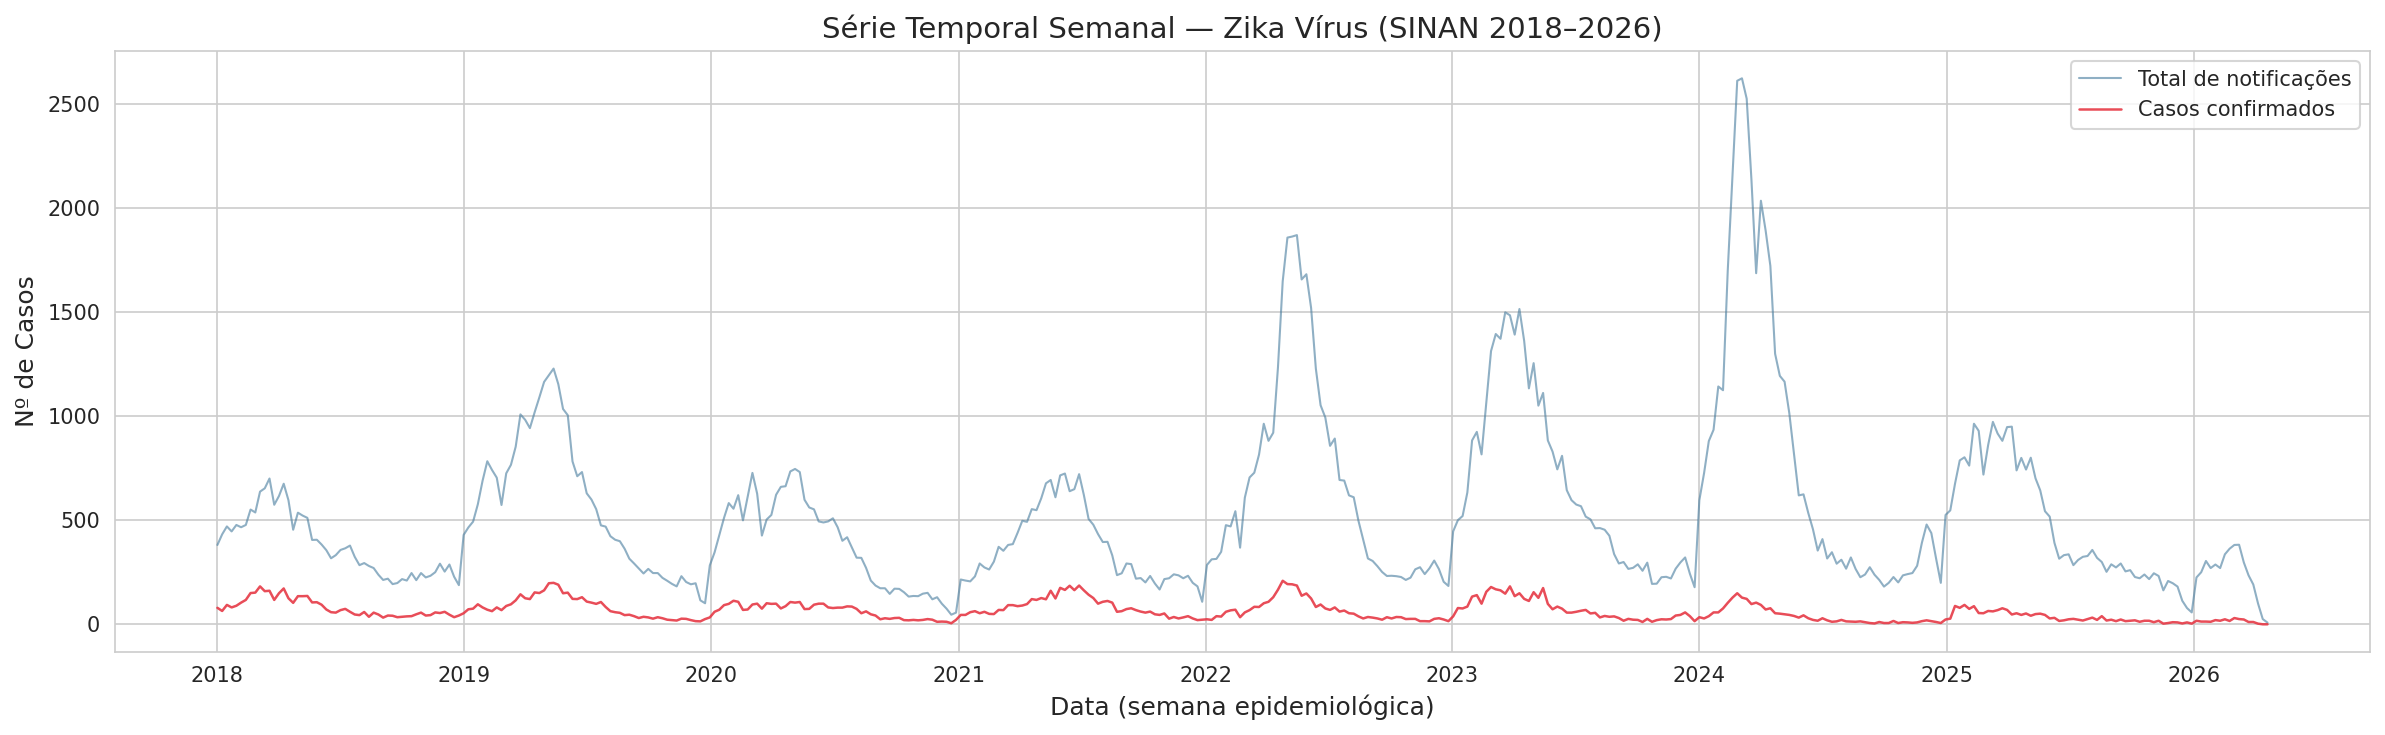

In [104]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df_semanal['ds'], df_semanal['total_casos'],
        label='Total de notificações', color=COR_SECUNDARIA, alpha=0.6, linewidth=1)
ax.plot(df_semanal['ds'], df_semanal['casos_confirmados'],
        label='Casos confirmados', color=COR_PRINCIPAL, alpha=0.9, linewidth=1.2)

ax.set_title('Série Temporal Semanal — Zika Vírus (SINAN 2018–2026)')
ax.set_xlabel('Data (semana epidemiológica)')
ax.set_ylabel('Nº de Casos')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

### 1.3 — Decomposição sazonal (Tendência + Sazonalidade + Resíduo)

Utiliza decomposição aditiva com período de 52 semanas (1 ano) para separar
 os 3 componentes da série.

Semanas na série: 434
Intervalo: 2018-01-01 a 2026-04-20


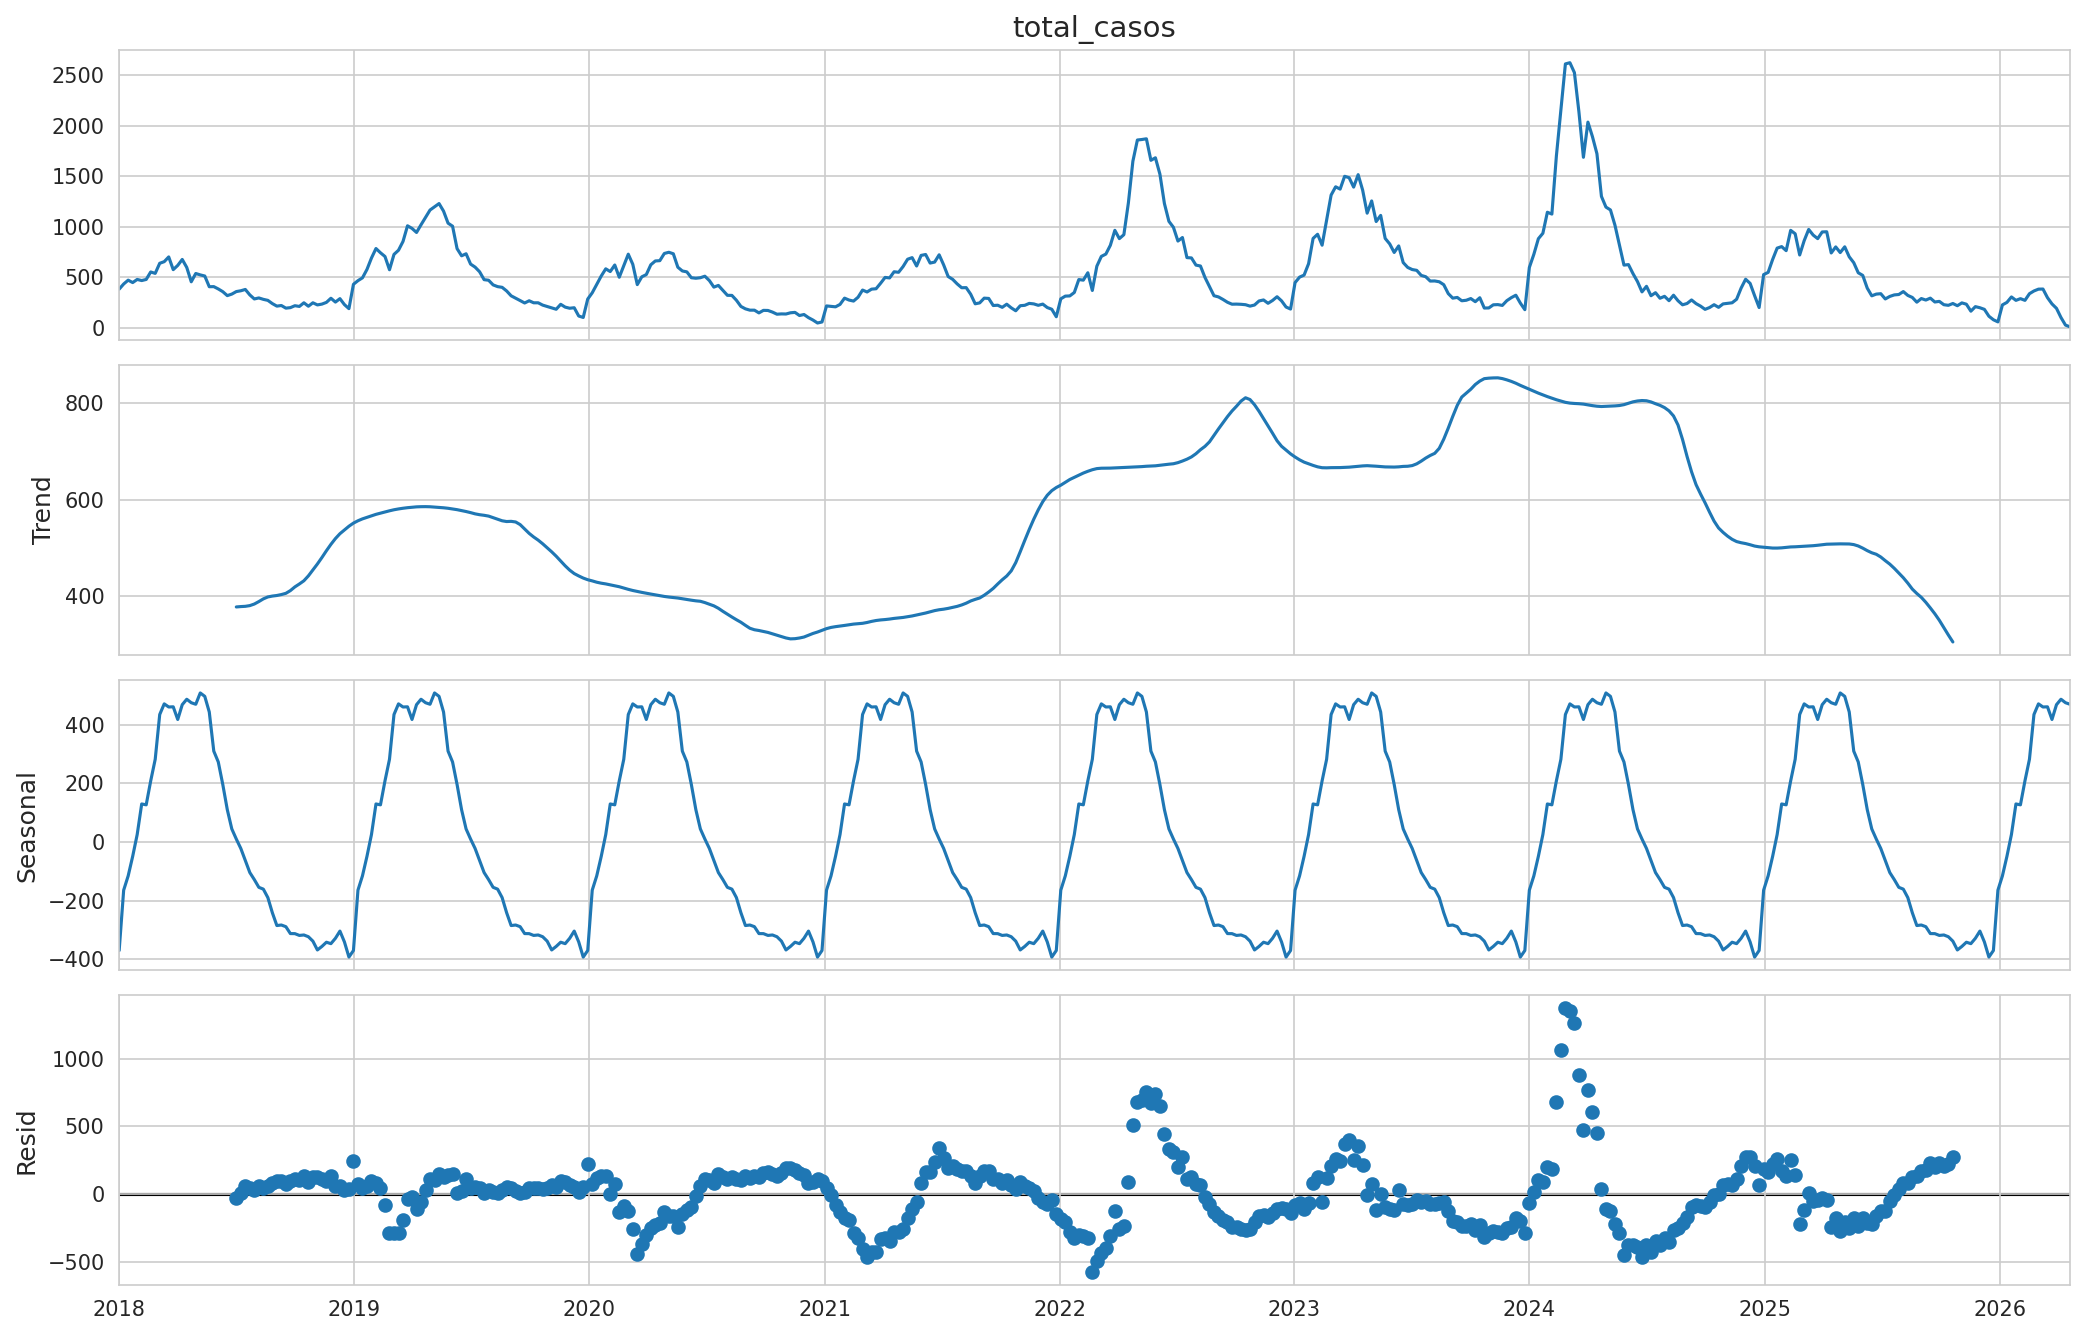

Decomposição concluída.


In [105]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Usa o df_semanal já carregado e filtrado (2018-2026) das células acima.
print(f'Semanas na série: {len(df_semanal)}')
print(f'Intervalo: {df_semanal["ds"].min().date()} a {df_semanal["ds"].max().date()}')

# Série semanal regular para a decomposição
ts = (df_semanal
      .set_index('ds')['total_casos']
      .resample('W-MON')
      .sum()
      .fillna(0))

# Decomposição aditiva, período anual (52 semanas)
resultado = seasonal_decompose(ts, model='additive', period=52)

fig = resultado.plot()
fig.set_size_inches(14, 9)
plt.tight_layout()
plt.savefig('decomposicao_sazonal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Decomposição concluída.')

**Interpretação:**
- **Trend (Tendência)**: direção geral da série — Zika em alta ou queda?
- **Seasonal (Sazonalidade)**: padrão que se repete anualmente — pico no verão?
- **Residual (Resíduo)**: variação não explicada — surtos atípicos, outliers.

### 1.4 — Boxplot de sazonalidade mensal

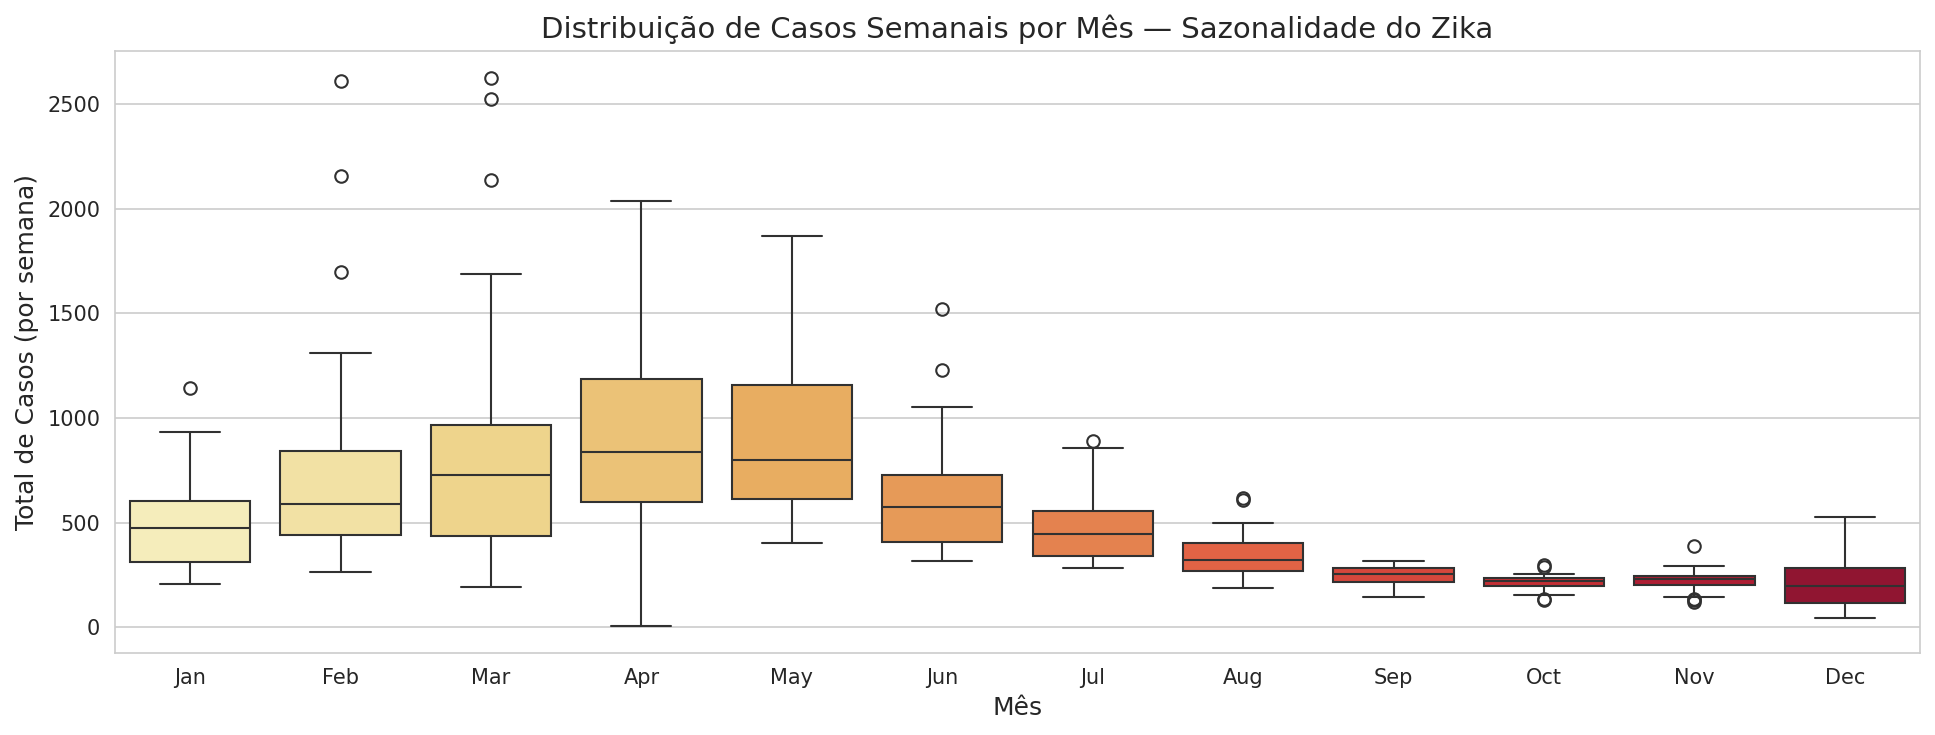

✅ Gráfico salvo: sazonalidade_mensal.png


In [106]:
df_semanal['mes'] = df_semanal['ds'].dt.month
df_semanal['nome_mes'] = df_semanal['ds'].dt.strftime('%b')  # Jan, Feb...

# Ordenação correta dos meses
ordem_meses = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df_semanal, x='nome_mes', y='total_casos',
            order=ordem_meses, palette='YlOrRd', ax=ax)

ax.set_title('Distribuição de Casos Semanais por Mês — Sazonalidade do Zika')
ax.set_xlabel('Mês')
ax.set_ylabel('Total de Casos (por semana)')

plt.tight_layout()
plt.savefig('sazonalidade_mensal.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo: sazonalidade_mensal.png')

### 1.5 — Heatmap: Semana Epidemiológica × Ano

Permite visualizar em qual semana e ano ocorreram os maiores surtos.

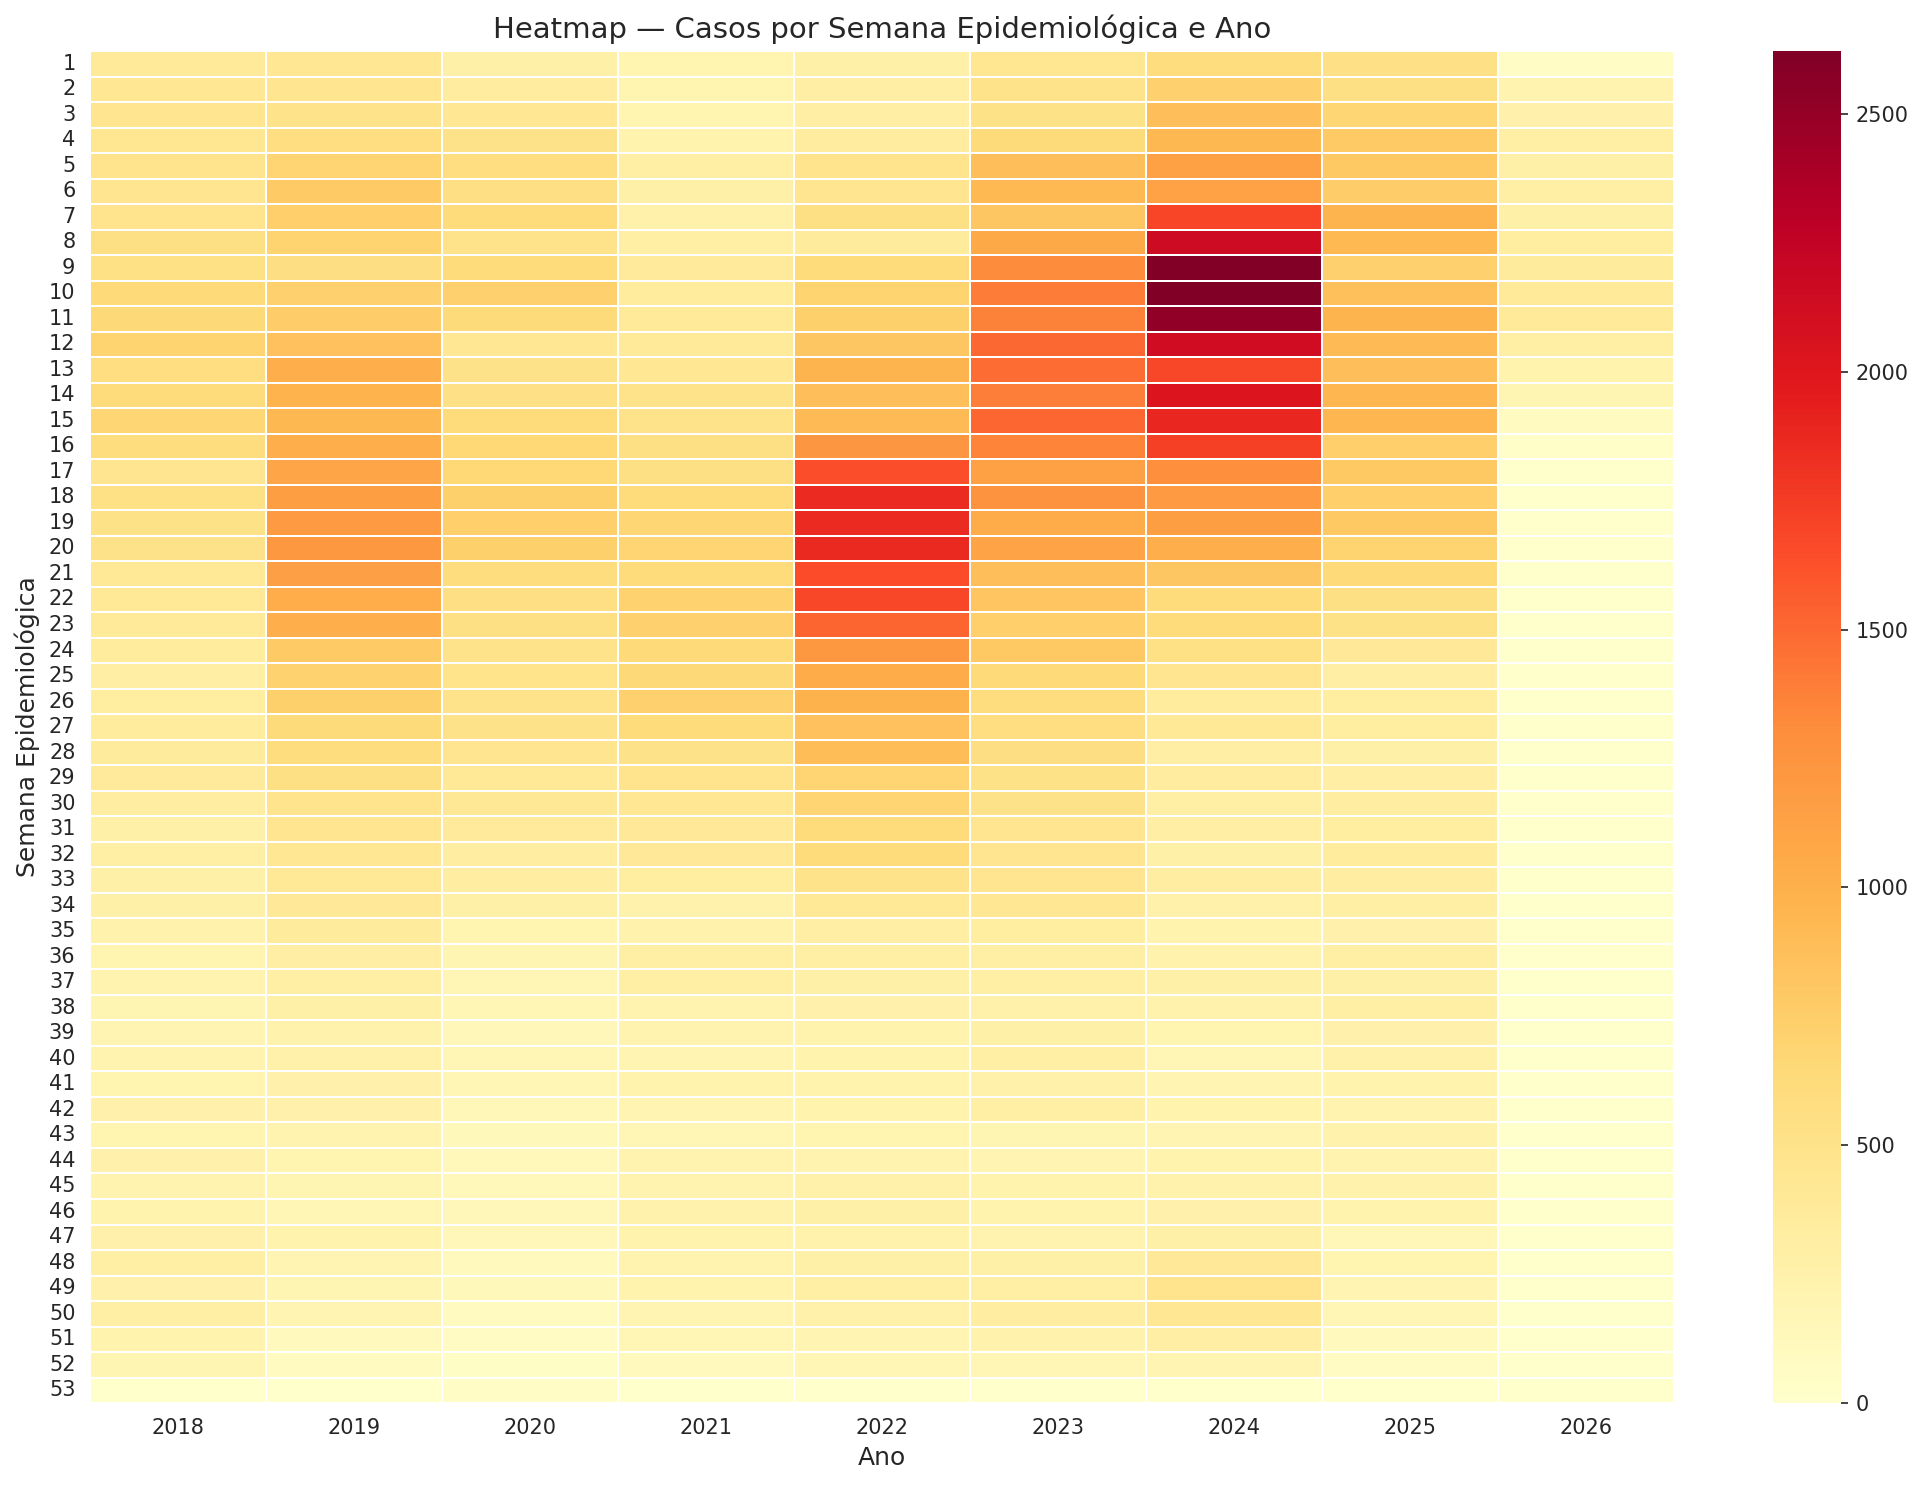

✅ Gráfico salvo: heatmap_semana_ano.png


In [107]:
pivot_sem = df_semanal.pivot_table(
    index='sem_pri', columns='nu_ano',
    values='total_casos', fill_value=0
)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(pivot_sem, cmap='YlOrRd', linewidths=0.1, ax=ax)
ax.set_title('Heatmap — Casos por Semana Epidemiológica e Ano')
ax.set_xlabel('Ano')
ax.set_ylabel('Semana Epidemiológica')

plt.tight_layout()
plt.savefig('heatmap_semana_ano.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo: heatmap_semana_ano.png')

---
## 🗺️ Etapa 2 — Tendência por UF

Objetivo: identificar quais Unidades Federativas concentram mais casos e
 como a incidência evoluiu ao longo dos anos.

### 2.1 — Extração dos dados

In [108]:
df_uf = query_df('SELECT * FROM vw_casos_uf_ano;')
# Colunas: sg_uf | nu_ano | total_notificacoes | casos_confirmados

print(f'Registros: {len(df_uf)}')
print(f'UFs presentes: {df_uf["sg_uf"].nunique()}')
df_uf.head(10)

Registros: 243
UFs presentes: 27


,sg_uf,nu_ano,total_notificacoes,casos_confirmados
0,RJ,2018,3994,1360
1,GO,2018,2063,418
2,BA,2018,1523,313
3,SP,2018,1435,140
4,TO,2018,1310,76
5,RN,2018,1185,69
6,MT,2018,1083,410
7,MG,2018,1013,86
8,PA,2018,800,77
9,PE,2018,786,60


### 2.2 — Heatmap: UF × Ano (Casos Confirmados)

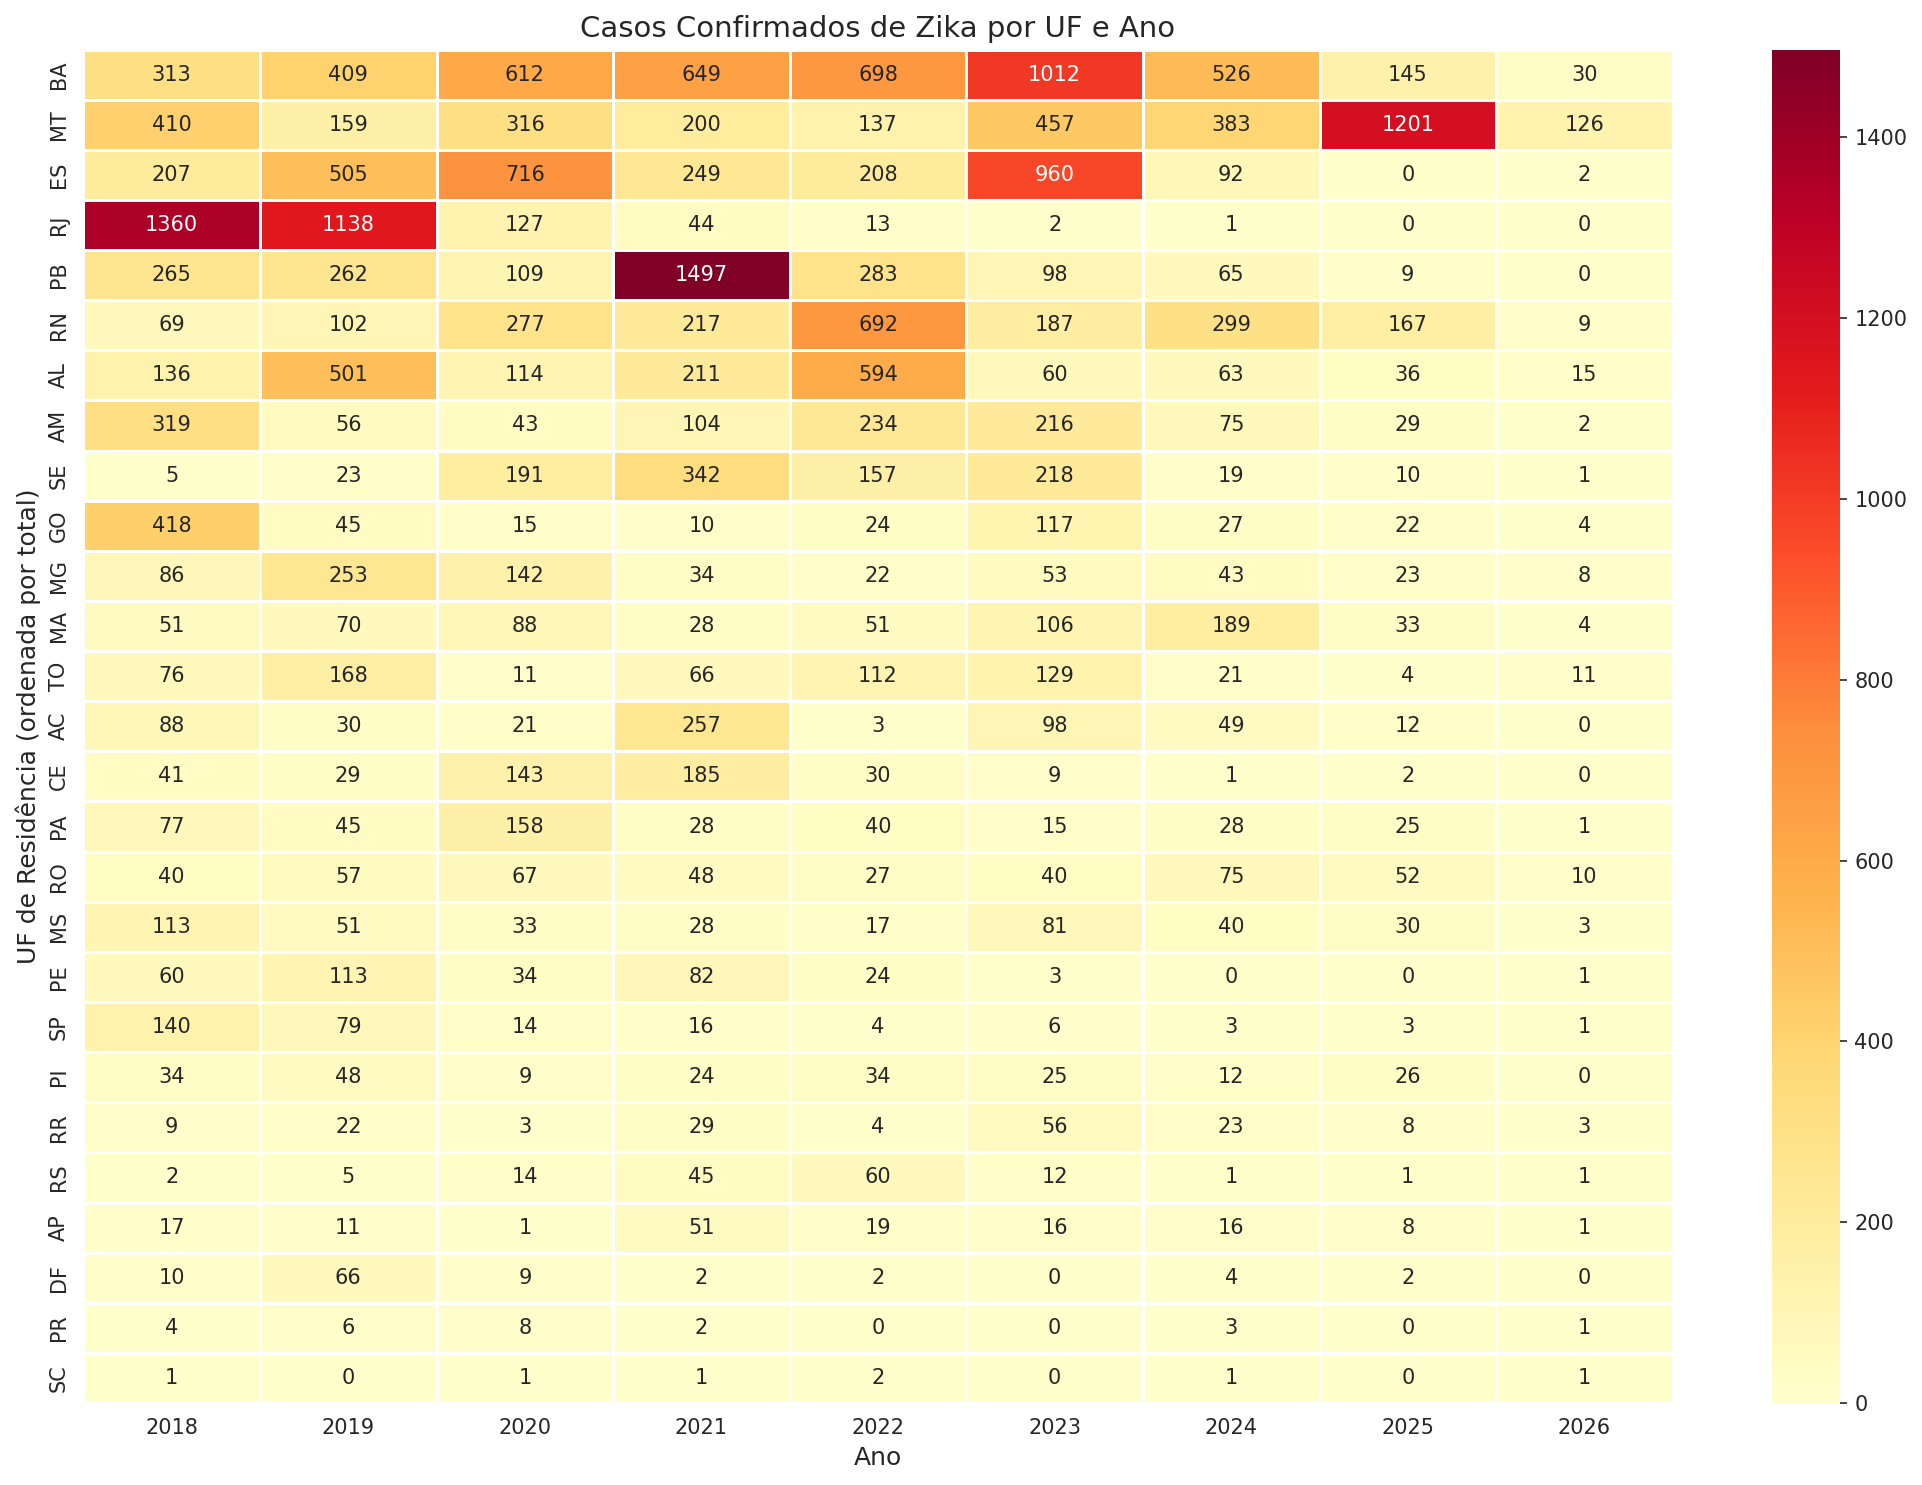

✅ Gráfico salvo: heatmap_uf_ano.png


In [109]:
pivot_uf = df_uf.pivot_table(
    index='sg_uf', columns='nu_ano',
    values='casos_confirmados', fill_value=0
)

# Ordena UFs pelo total acumulado (decrescente)
ordem_uf = pivot_uf.sum(axis=1).sort_values(ascending=False).index
pivot_uf = pivot_uf.loc[ordem_uf]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(pivot_uf, annot=True, fmt='g', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('Casos Confirmados de Zika por UF e Ano')
ax.set_xlabel('Ano')
ax.set_ylabel('UF de Residência (ordenada por total)')

plt.tight_layout()
plt.savefig('heatmap_uf_ano.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo: heatmap_uf_ano.png')

### 2.3 — Evolução temporal: Top 5 UFs

Top 5 UFs: ['BA', 'MT', 'ES', 'RJ', 'PB']


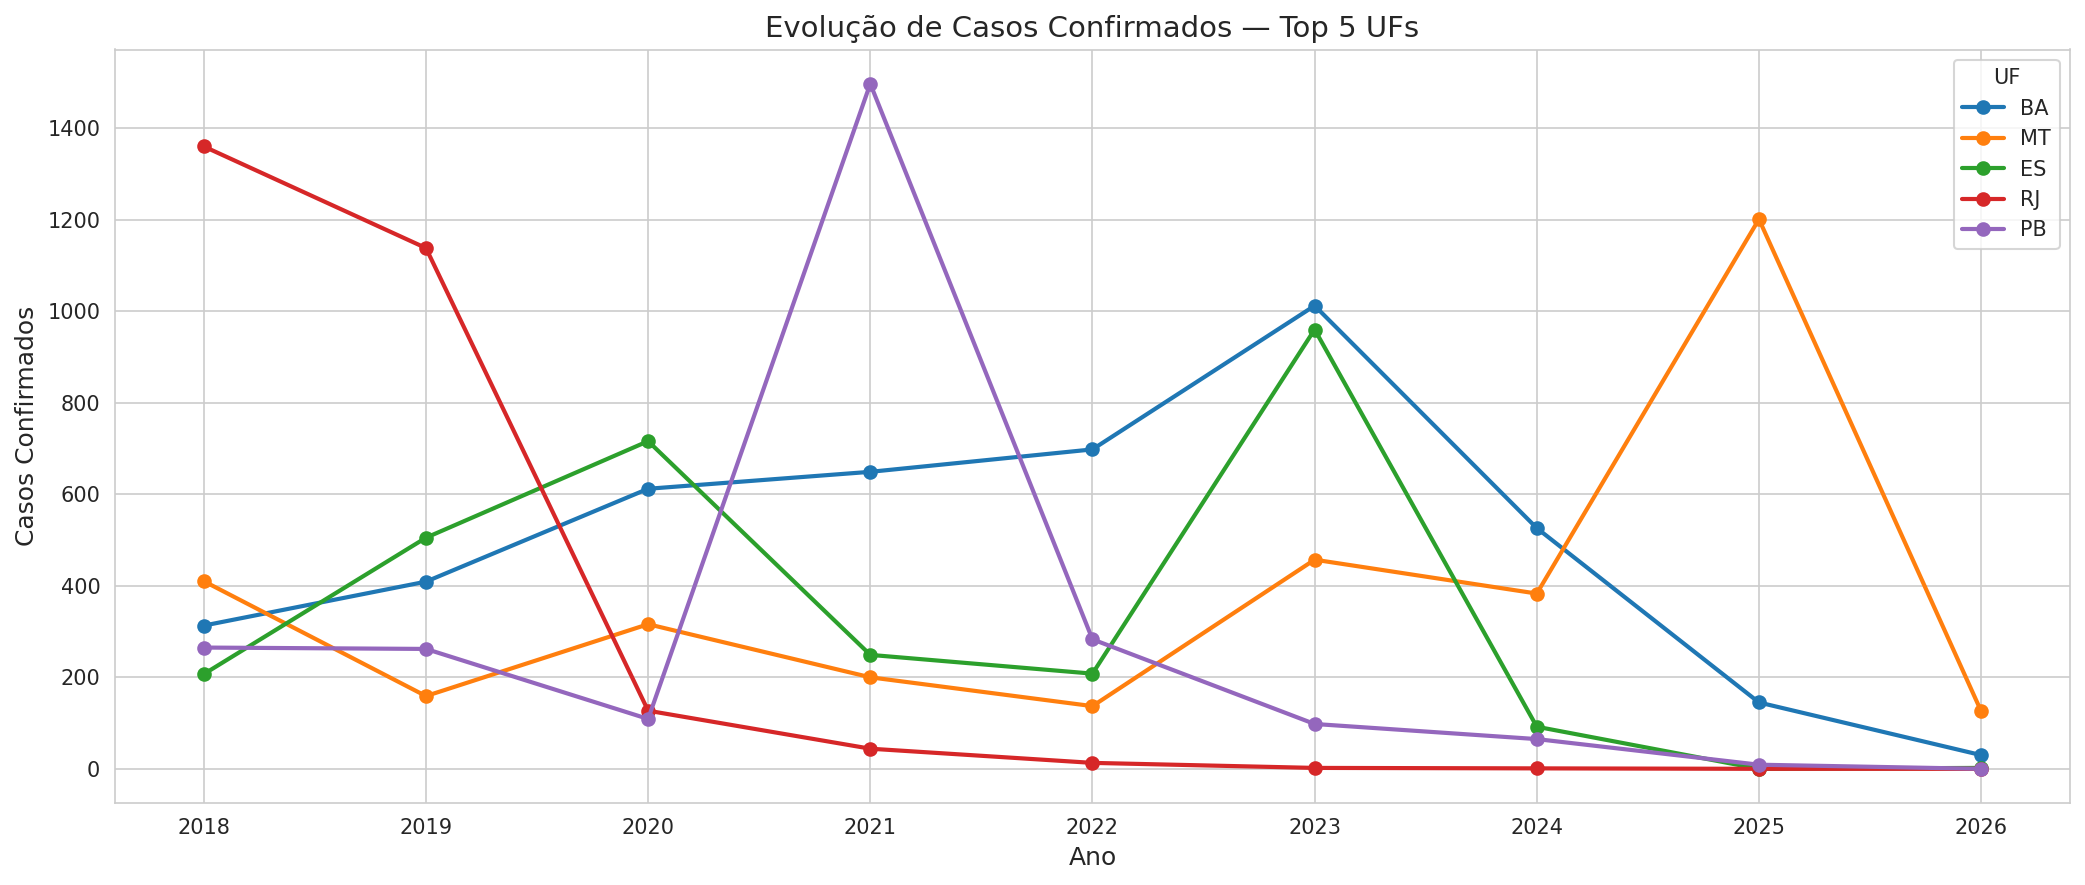

✅ Gráfico salvo: tendencia_top5_uf.png


In [110]:
# Top 5 UFs com mais casos confirmados acumulados
top5_ufs = (df_uf.groupby('sg_uf')['casos_confirmados']
            .sum().nlargest(5).index.tolist())
print(f'Top 5 UFs: {top5_ufs}')

fig, ax = plt.subplots(figsize=(14, 6))
for i, uf in enumerate(top5_ufs):
    dados_uf = df_uf[df_uf['sg_uf'] == uf].sort_values('nu_ano')
    ax.plot(dados_uf['nu_ano'], dados_uf['casos_confirmados'],
            marker='o', label=uf, color=PALETA_UFS[i], linewidth=2)

ax.set_title('Evolução de Casos Confirmados — Top 5 UFs')
ax.set_xlabel('Ano')
ax.set_ylabel('Casos Confirmados')
ax.legend(title='UF')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('tendencia_top5_uf.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo: tendencia_top5_uf.png')

### 2.4 — Ranking acumulado por UF (barras horizontais)

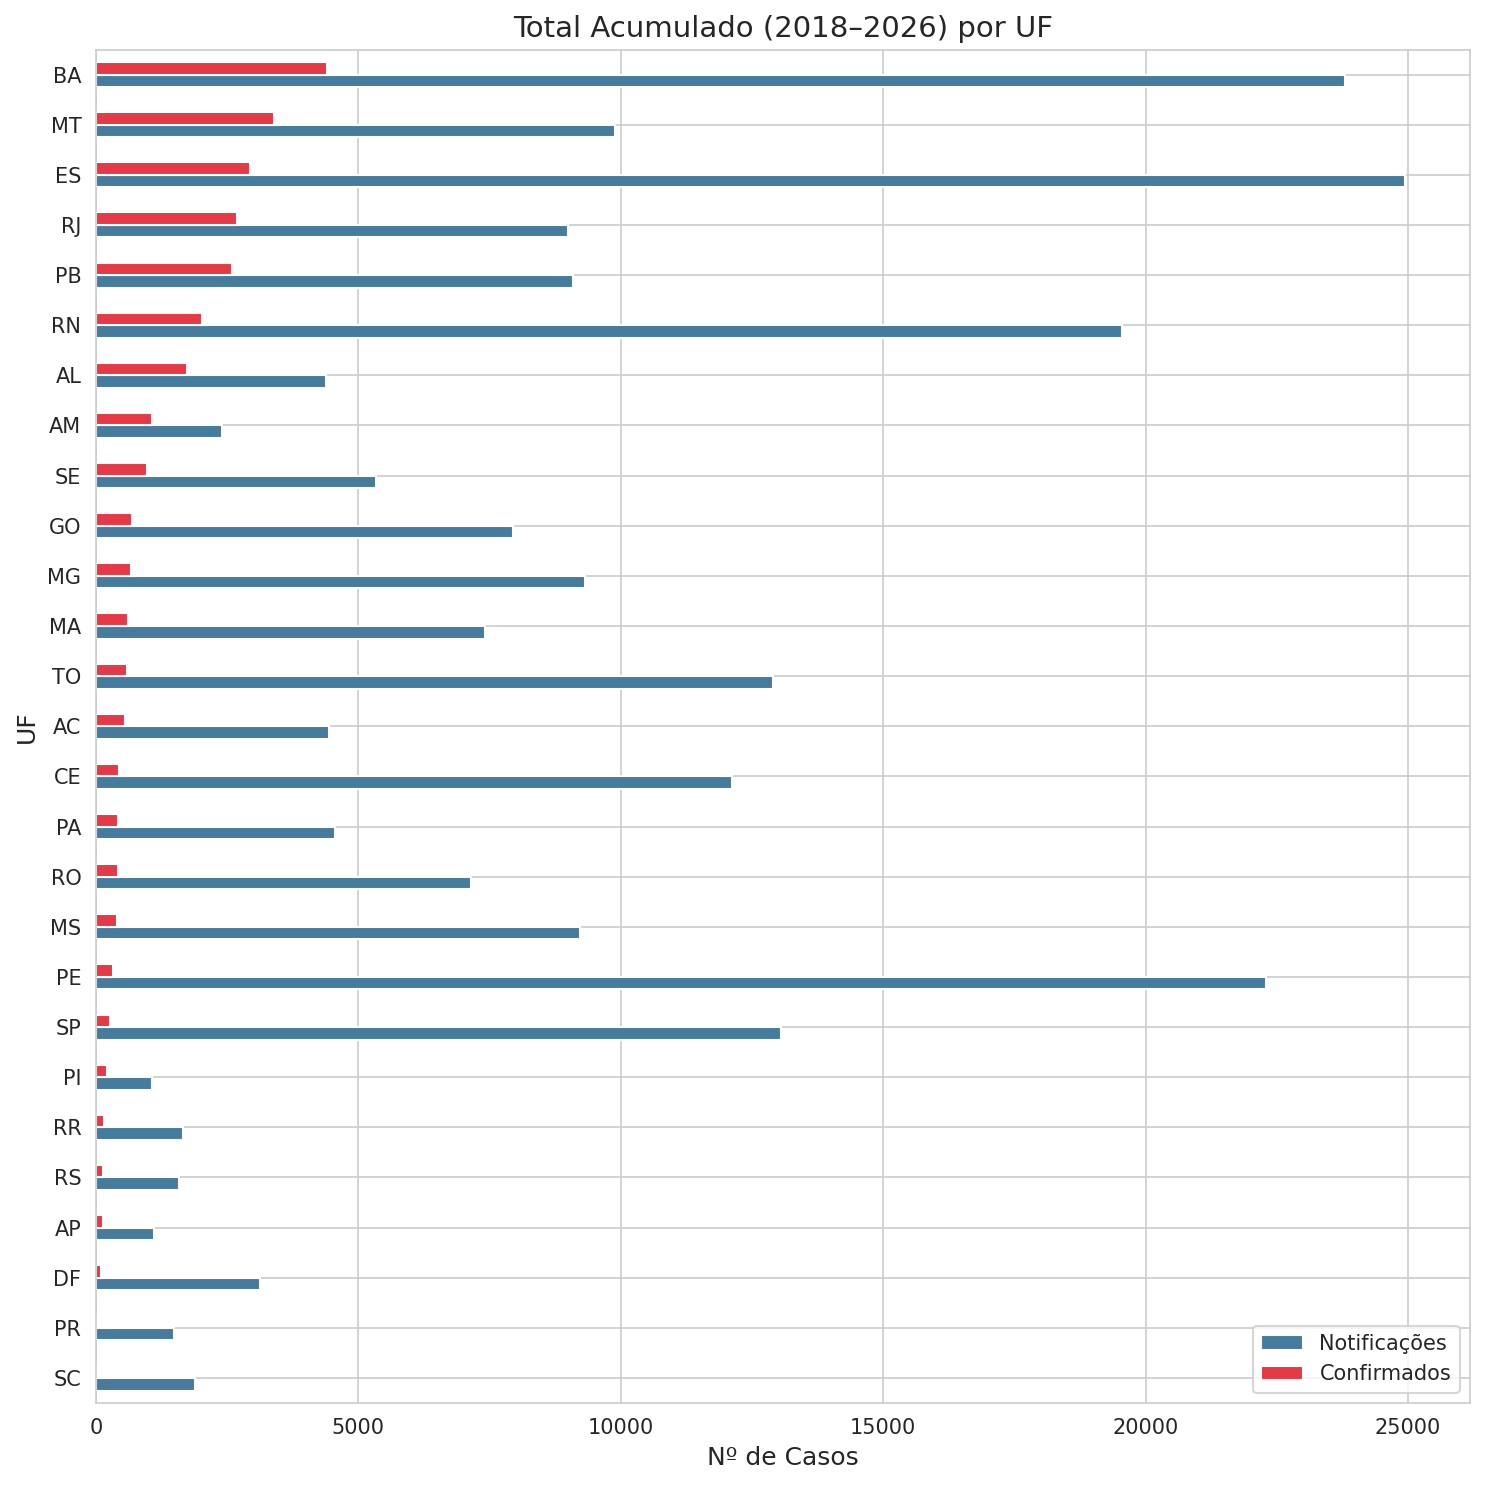

✅ Gráfico salvo: ranking_uf_acumulado.png


In [111]:
ranking = (df_uf.groupby('sg_uf')[['total_notificacoes', 'casos_confirmados']]
           .sum().sort_values('casos_confirmados', ascending=True))

fig, ax = plt.subplots(figsize=(10, 10))
ranking.plot.barh(ax=ax, color=[COR_SECUNDARIA, COR_PRINCIPAL])
ax.set_title('Total Acumulado (2018–2026) por UF')
ax.set_xlabel('Nº de Casos')
ax.set_ylabel('UF')
ax.legend(['Notificações', 'Confirmados'])

plt.tight_layout()
plt.savefig('ranking_uf_acumulado.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo: ranking_uf_acumulado.png')

---
## 🔮 Etapa 3 — Previsão de Casos com Prophet

O [Prophet](https://facebook.github.io/prophet/) é um modelo aditivo de séries temporais
 desenvolvido pelo Meta, ideal para dados com **sazonalidade forte** e **gaps**.

Modelo: $y(t) = g(t) + s(t) + h(t) + \epsilon_t$
- $g(t)$: tendência (linear ou logística)
- $s(t)$: sazonalidade (Fourier)
- $h(t)$: efeitos de feriados/eventos
- $\epsilon_t$: ruído

### 3.1 — Preparação dos dados para o Prophet

In [112]:
# Prophet exige 2 colunas: ds (data) e y (valor). df_semanal já está limpo.
df_prophet = df_semanal[['ds', 'total_casos']].rename(columns={'total_casos': 'y'})
df_prophet = df_prophet.sort_values('ds').reset_index(drop=True)

print(f'Registros para treino: {len(df_prophet)}')
print(f'Período: {df_prophet["ds"].min().date()} → {df_prophet["ds"].max().date()}')
df_prophet.tail()

Registros para treino: 434
Período: 2018-01-01 → 2026-04-20


,ds,y
429,2026-03-23,235
430,2026-03-30,191
431,2026-04-06,100
432,2026-04-13,25
433,2026-04-20,8


### 3.2 — Treinamento do modelo

In [113]:
from prophet import Prophet

modelo = Prophet(
    seasonality_mode='additive',    # sazonalidade aditiva (padrão epidemiológico)
    yearly_seasonality=True,         # captura ciclo anual
    weekly_seasonality=False,        # dados semanais, não diários
    daily_seasonality=False,
    changepoint_prior_scale=0.05,    # controla flexibilidade da tendência
    interval_width=0.95              # intervalo de confiança de 95%
)

modelo.fit(df_prophet)
print('✅ Modelo treinado com sucesso.')

23:17:53 - cmdstanpy - INFO - Chain [1] start processing
23:17:53 - cmdstanpy - INFO - Chain [1] done processing


✅ Modelo treinado com sucesso.


### 3.3 — Previsão (52 semanas à frente)

In [114]:
# Gera dataframe com datas futuras (1 ano = 52 semanas)
futuro = modelo.make_future_dataframe(periods=52, freq='W')
previsao = modelo.predict(futuro)

print(f'Previsão gerada até: {previsao["ds"].max().date()}')
print(f'\nÚltimas 5 semanas previstas:')
previsao[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

Previsão gerada até: 2027-04-18

Últimas 5 semanas previstas:


,ds,yhat,yhat_lower,yhat_upper
481,2027-03-21,415.045984,-106.645114,930.530946
482,2027-03-28,394.428208,-94.436555,916.064508
483,2027-04-04,372.382626,-192.766700,905.049177
484,2027-04-11,363.035244,-102.137875,875.310327
485,2027-04-18,378.470087,-143.575982,871.206393


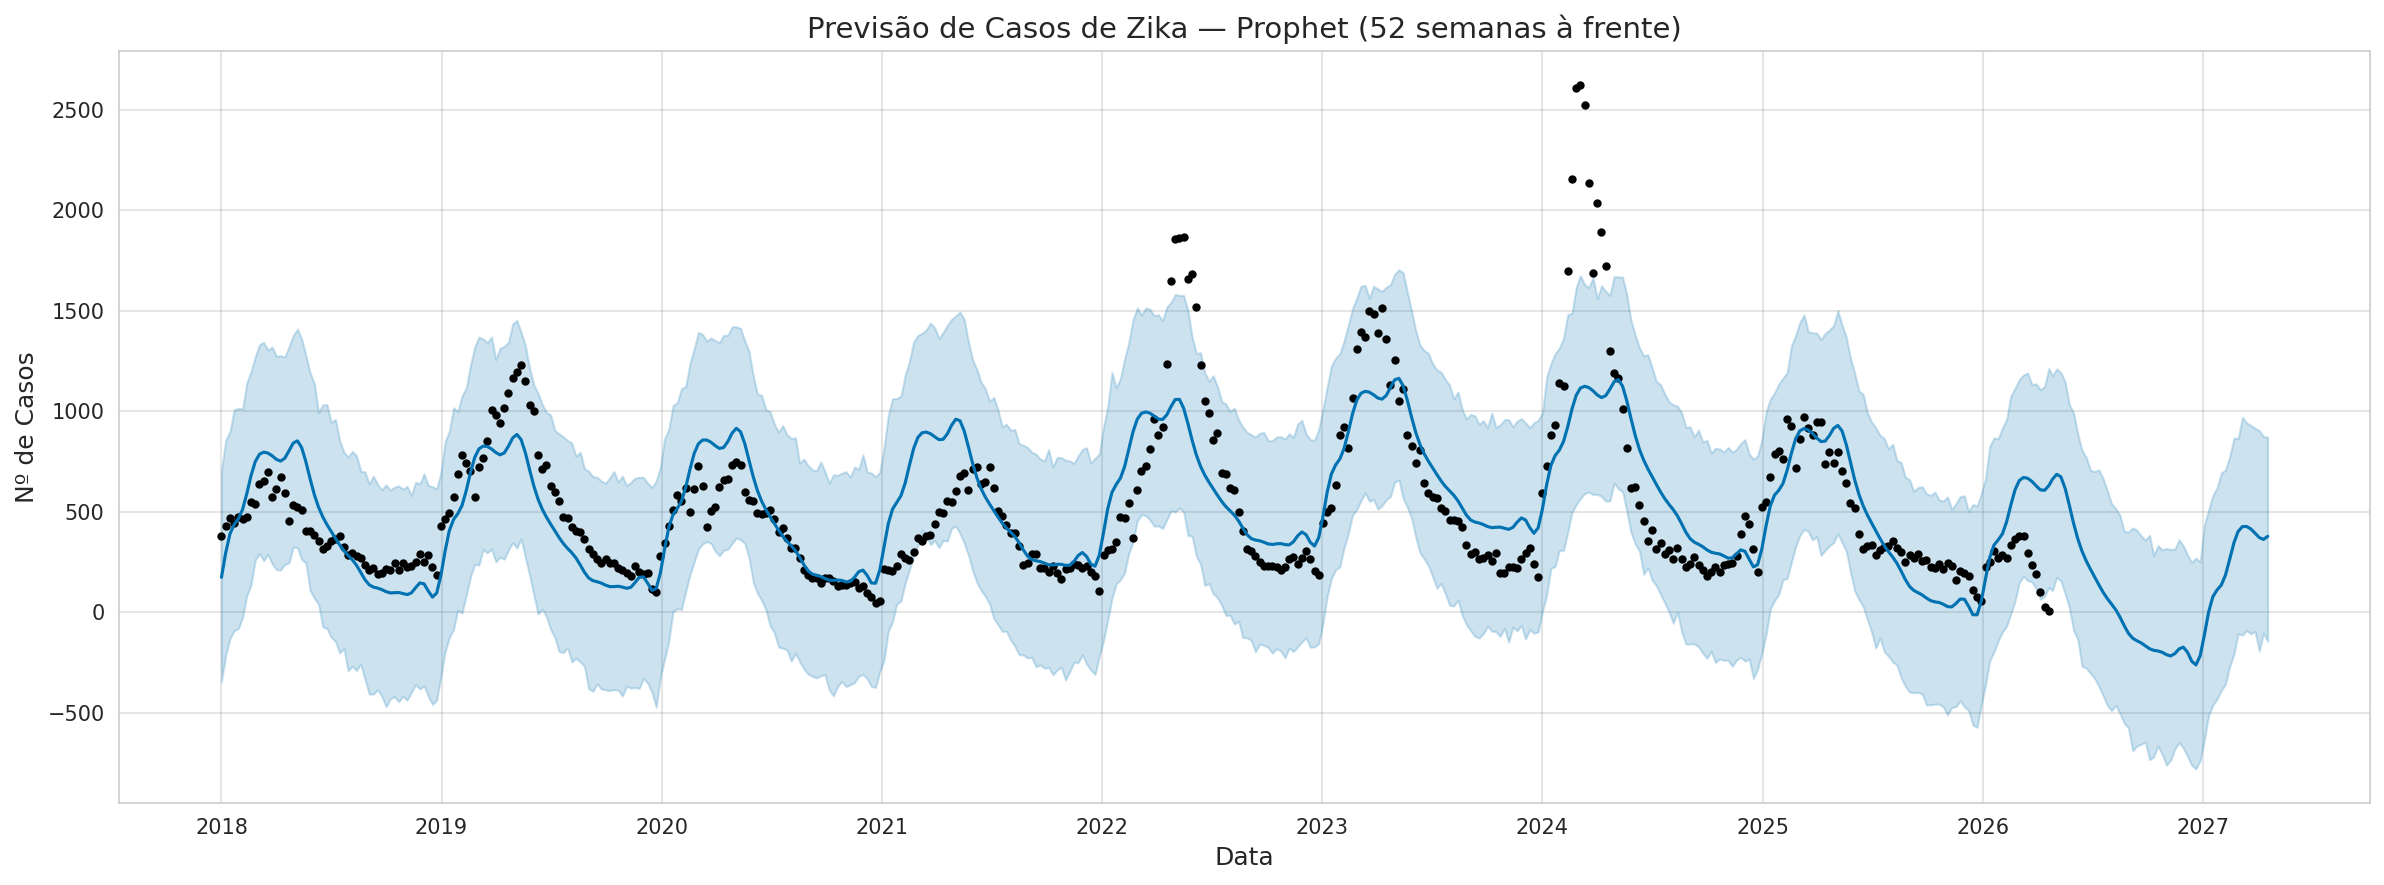

✅ Gráfico salvo: prophet_previsao.png


In [115]:
# ── Gráfico principal: histórico + previsão ──
fig1 = modelo.plot(previsao)
fig1.set_size_inches(16, 6)
plt.title('Previsão de Casos de Zika — Prophet (52 semanas à frente)', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Nº de Casos')

plt.tight_layout()
plt.savefig('prophet_previsao.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo: prophet_previsao.png')

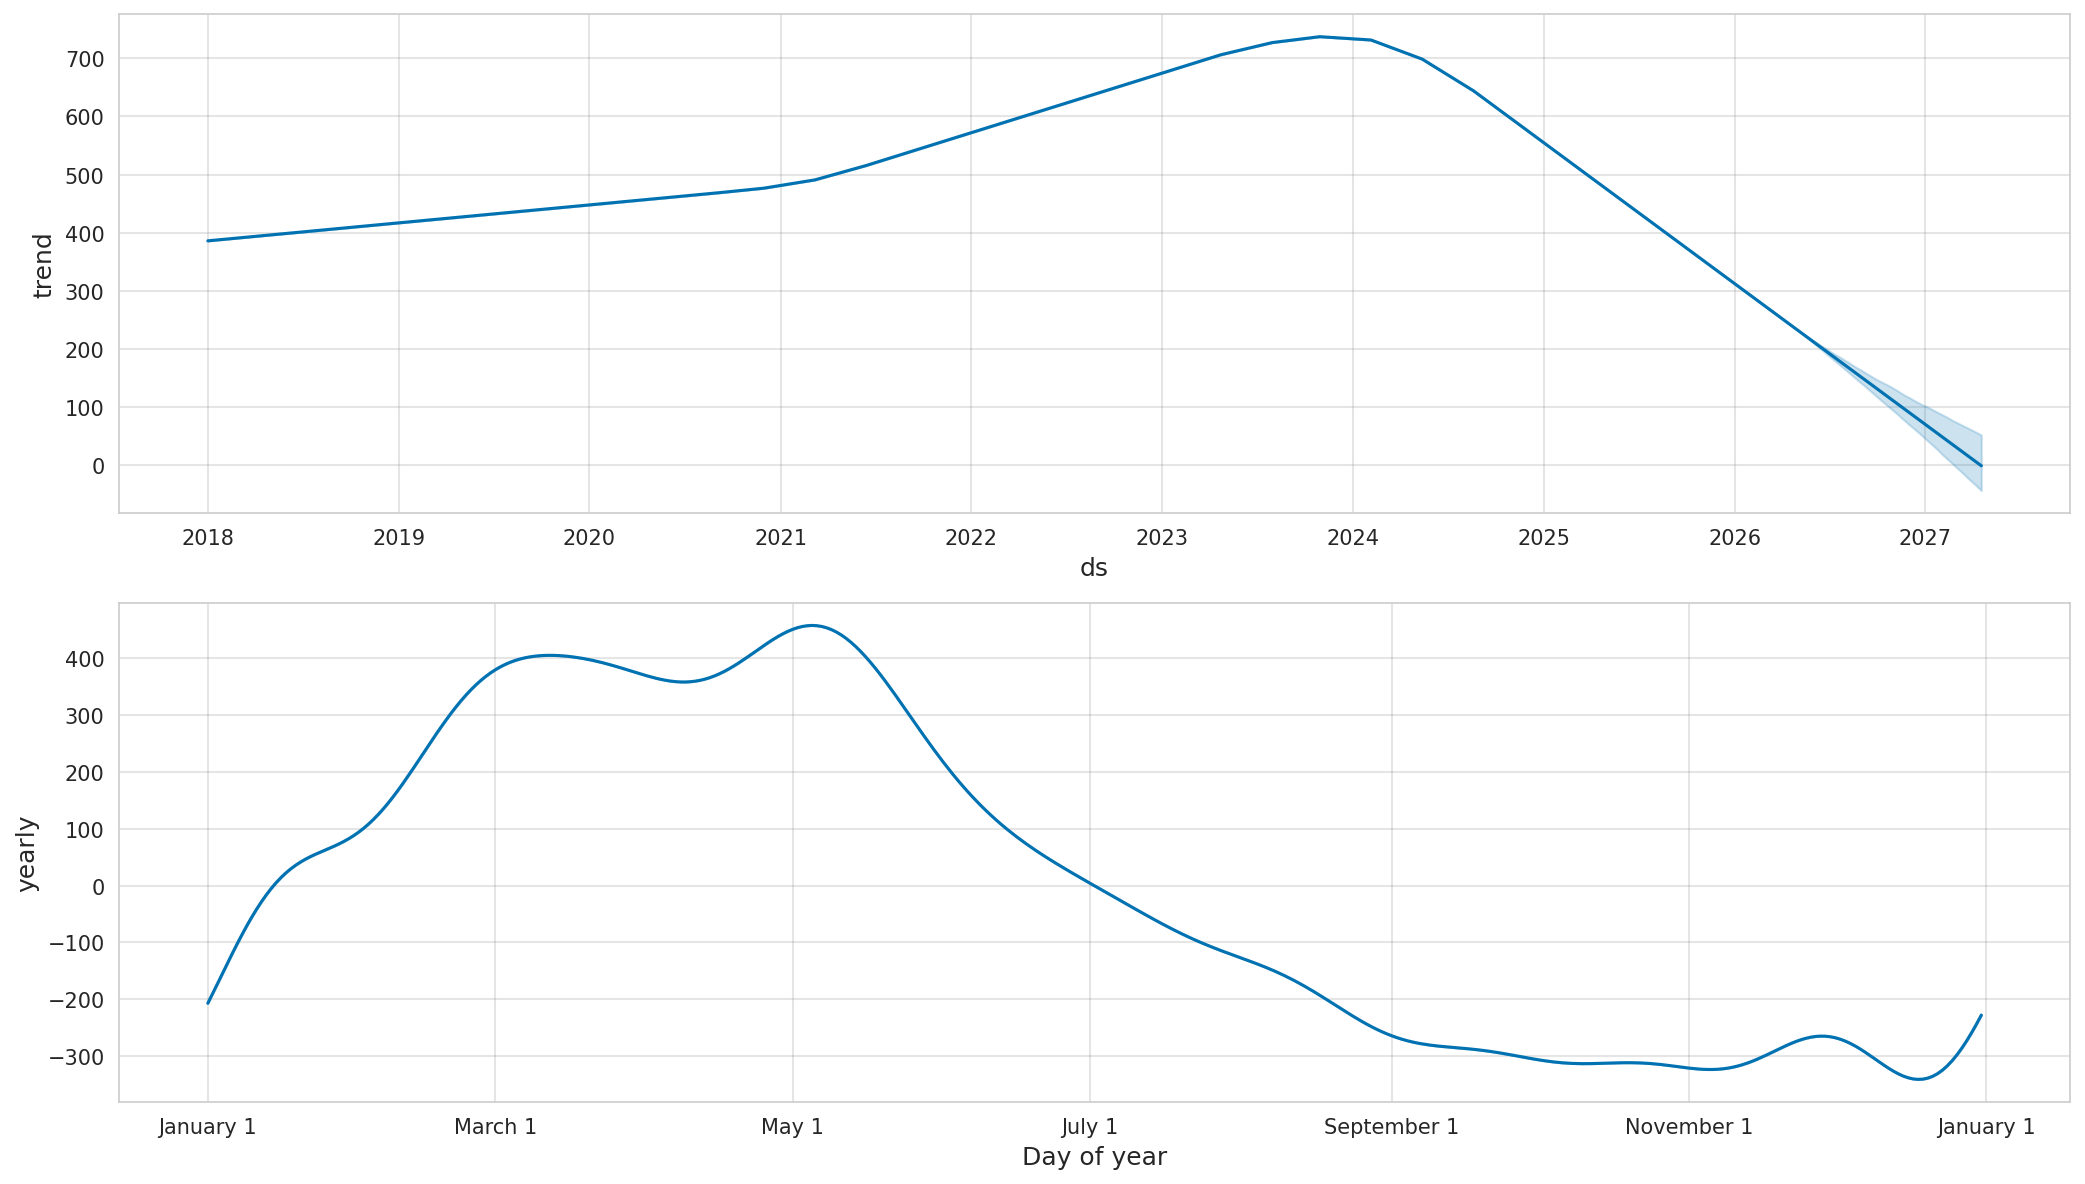

✅ Gráfico salvo: prophet_componentes.png


In [116]:
# ── Componentes (tendência + sazonalidade anual) ──
fig2 = modelo.plot_components(previsao)
fig2.set_size_inches(14, 8)

plt.tight_layout()
plt.savefig('prophet_componentes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo: prophet_componentes.png')

### 3.4 — Validação cruzada (Cross-Validation)

Avalia a qualidade preditiva do modelo usando janelas deslizantes:
- **initial**: período mínimo de treino (730 dias = 2 anos)
- **period**: a cada 30 dias faz novo corte
- **horizon**: prevê 90 dias à frente em cada corte

In [117]:
# Reconstrói a série do zero, na ordem certa, numa célula só.

# 1. Pega a série da view (já corrigida no banco)
df_semanal = query_df('SELECT * FROM vw_serie_temporal_semanal;')
print("Linhas vindas da view:", len(df_semanal))

# 2. Monta a data a partir de ano + semana ISO
def semana_para_data(row):
    try:
        return datetime.fromisocalendar(int(row['nu_ano']), int(row['sem_pri']), 1)
    except (ValueError, TypeError):
        return pd.NaT

df_semanal['ds'] = pd.to_datetime(df_semanal.apply(semana_para_data, axis=1))
df_semanal = df_semanal.dropna(subset=['ds']).sort_values('ds').reset_index(drop=True)
print("Após conversão de data:", len(df_semanal))

# 3. Cria o df_prophet (ds + y) e filtra para 2018-2026
df_prophet = df_semanal[['ds', 'total_casos']].rename(columns={'total_casos': 'y'})
df_prophet = df_prophet[
    (df_prophet['ds'] >= '2018-01-01') &
    (df_prophet['ds'] <= '2026-12-31')
].sort_values('ds').reset_index(drop=True)

print("Linhas finais no df_prophet:", len(df_prophet))
print("Valores não-nulos em y:", df_prophet['y'].notna().sum())
print("Período:", df_prophet['ds'].min().date(), "→", df_prophet['ds'].max().date())
print(df_prophet.head())

Linhas vindas da view: 584
Após conversão de data: 584
Linhas finais no df_prophet: 434
Valores não-nulos em y: 434
Período: 2018-01-01 → 2026-04-20
          ds    y
0 2018-01-01  381
1 2018-01-08  432
2 2018-01-15  470
3 2018-01-22  446
4 2018-01-29  477


In [118]:
from prophet import Prophet

modelo = Prophet(
    seasonality_mode='additive',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    interval_width=0.95
)
modelo.fit(df_prophet)
print('Modelo treinado com sucesso.')

23:17:54 - cmdstanpy - INFO - Chain [1] start processing
23:17:54 - cmdstanpy - INFO - Chain [1] done processing


Modelo treinado com sucesso.


In [119]:
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(
    modelo,
    initial='1095 days',
    period='180 days',
    horizon='180 days'
)

df_metricas = performance_metrics(df_cv)
print('=== Métricas de Validação Cruzada ===')
print(df_metricas[['horizon', 'rmse', 'mae', 'mape']].to_string(index=False))

  0%|          | 0/10 [00:00<?, ?it/s]23:17:54 - cmdstanpy - INFO - Chain [1] start processing
23:17:54 - cmdstanpy - INFO - Chain [1] done processing
23:17:54 - cmdstanpy - INFO - Chain [1] start processing
23:17:54 - cmdstanpy - INFO - Chain [1] done processing
 20%|██        | 2/10 [00:00<00:00, 16.69it/s]23:17:54 - cmdstanpy - INFO - Chain [1] start processing
23:17:54 - cmdstanpy - INFO - Chain [1] done processing
23:17:54 - cmdstanpy - INFO - Chain [1] start processing
23:17:54 - cmdstanpy - INFO - Chain [1] done processing
 40%|████      | 4/10 [00:00<00:00, 16.66it/s]23:17:55 - cmdstanpy - INFO - Chain [1] start processing
23:17:55 - cmdstanpy - INFO - Chain [1] done processing
23:17:55 - cmdstanpy - INFO - Chain [1] start processing
23:17:55 - cmdstanpy - INFO - Chain [1] done processing
 60%|██████    | 6/10 [00:00<00:00, 16.25it/s]23:17:55 - cmdstanpy - INFO - Chain [1] start processing
23:17:55 - cmdstanpy - INFO - Chain [1] done processing
23:17:55 - cmdstanpy - INFO - Cha

=== Métricas de Validação Cruzada ===
 horizon       rmse        mae     mape
 17 days 354.953345 296.834122 0.551544
 18 days 356.373922 299.154409 0.573654
 19 days 383.276980 312.796607 0.567627
 20 days 396.079976 325.879101 0.577877
 21 days 393.452087 325.085154 0.597157
 22 days 385.517111 325.601756 0.604793
 23 days 378.272711 326.197762 0.613358
 24 days 386.284037 331.312567 0.624015
 25 days 386.574649 332.037647 0.631243
 26 days 403.708141 341.183660 0.620261
 27 days 425.023574 360.504178 0.651407
 28 days 422.034042 358.081576 0.660162
 29 days 414.956114 353.418443 0.642057
 30 days 412.847029 355.891723 0.651076
 31 days 413.937945 352.475778 0.647272
 32 days 410.878658 347.050599 0.638899
 33 days 403.657254 332.764093 0.602132
 34 days 417.525237 347.073961 0.623214
 35 days 412.705573 343.198667 0.632158
 36 days 401.615307 332.892742 0.597345
 37 days 390.727565 328.632129 0.598027
 38 days 380.364374 315.961628 0.582051
 39 days 374.866921 306.956687 0.566426
 4

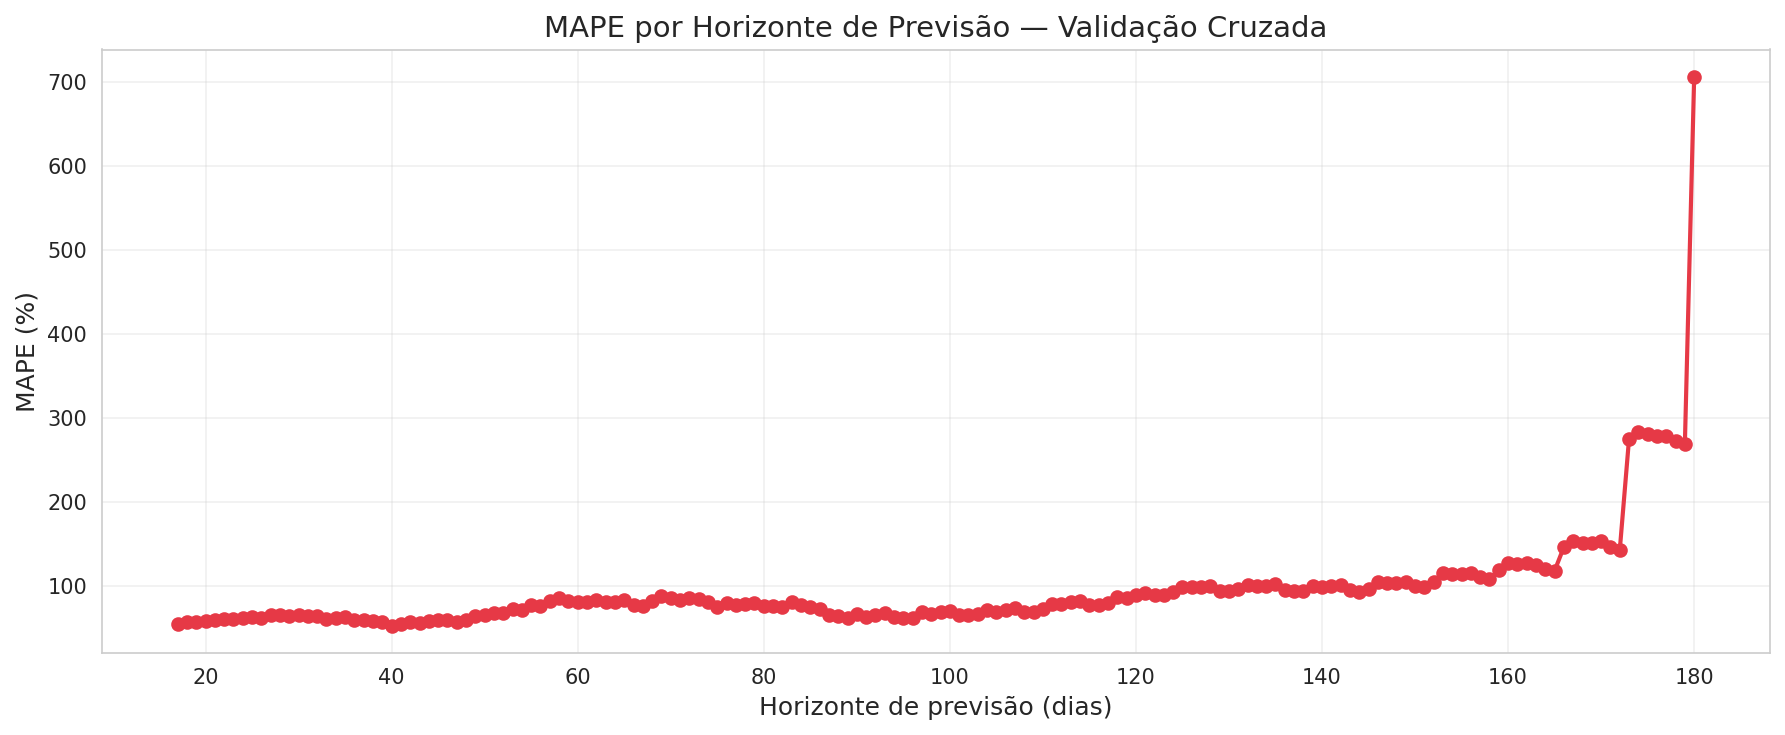

Gráfico salvo: prophet_cv_mape.png


In [120]:
# Gráfico de MAPE por horizonte — feito direto com matplotlib
# (evita o bug do plot_cross_validation_metric com pandas 3.0)
import matplotlib.pyplot as plt

# dias de horizonte no eixo x
df_metricas['horizon_dias'] = df_metricas['horizon'].dt.days

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_metricas['horizon_dias'], df_metricas['mape'] * 100,
        marker='o', color='#E63946', linewidth=2)
ax.set_title('MAPE por Horizonte de Previsão — Validação Cruzada')
ax.set_xlabel('Horizonte de previsão (dias)')
ax.set_ylabel('MAPE (%)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prophet_cv_mape.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: prophet_cv_mape.png')

### 3.5 — (Bônus) Prophet por UF — Top 5 estados

Gera previsões individualizadas para os 5 estados com maior incidência.

In [121]:
# ── Série semanal por UF (derivando ano/semana de dt_sin_pri, filtrada) ──
SQL_UF_SEMANAL = """
SELECT
    u.sg_uf,
    EXTRACT(ISOYEAR FROM c.dt_sin_pri)::INT AS nu_ano,
    EXTRACT(WEEK    FROM c.dt_sin_pri)::INT AS sem_pri,
    COUNT(*) AS total_casos
FROM tb_notificacao n
JOIN tb_dados_clinicos c           ON n.id_notificacao = c.id_notificacao
JOIN tb_geografia_epidemiologica g ON n.id_notificacao = g.id_notificacao
JOIN tb_municipio m                ON g.id_municipio_resi = m.id_municipio
JOIN tb_uf u                       ON m.id_uf = u.id_uf
WHERE c.dt_sin_pri BETWEEN '2018-01-01' AND '2026-12-31'
GROUP BY u.sg_uf, 2, 3
ORDER BY u.sg_uf, 2, 3;
"""
df_uf_sem = query_df(SQL_UF_SEMANAL)
print(f'Registros carregados: {len(df_uf_sem)}')

Registros carregados: 10705


23:17:57 - cmdstanpy - INFO - Chain [1] start processing
23:17:57 - cmdstanpy - INFO - Chain [1] done processing



Treinando Prophet para: BA


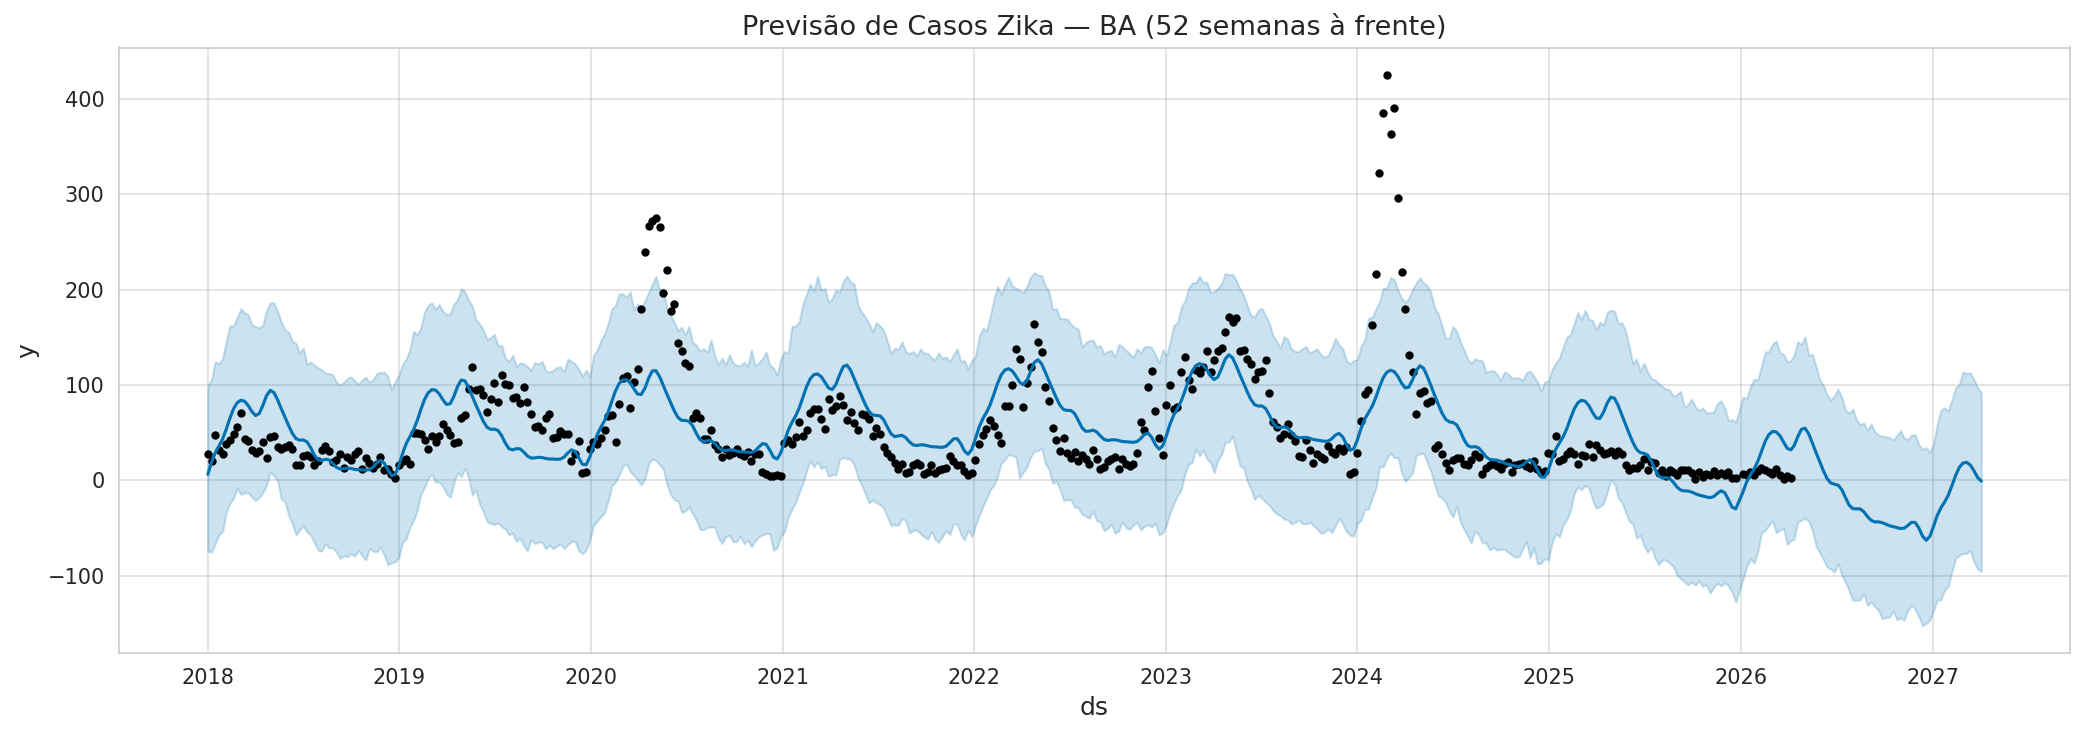

23:17:57 - cmdstanpy - INFO - Chain [1] start processing
23:17:57 - cmdstanpy - INFO - Chain [1] done processing


  Gráfico salvo: prophet_BA.png

Treinando Prophet para: MT


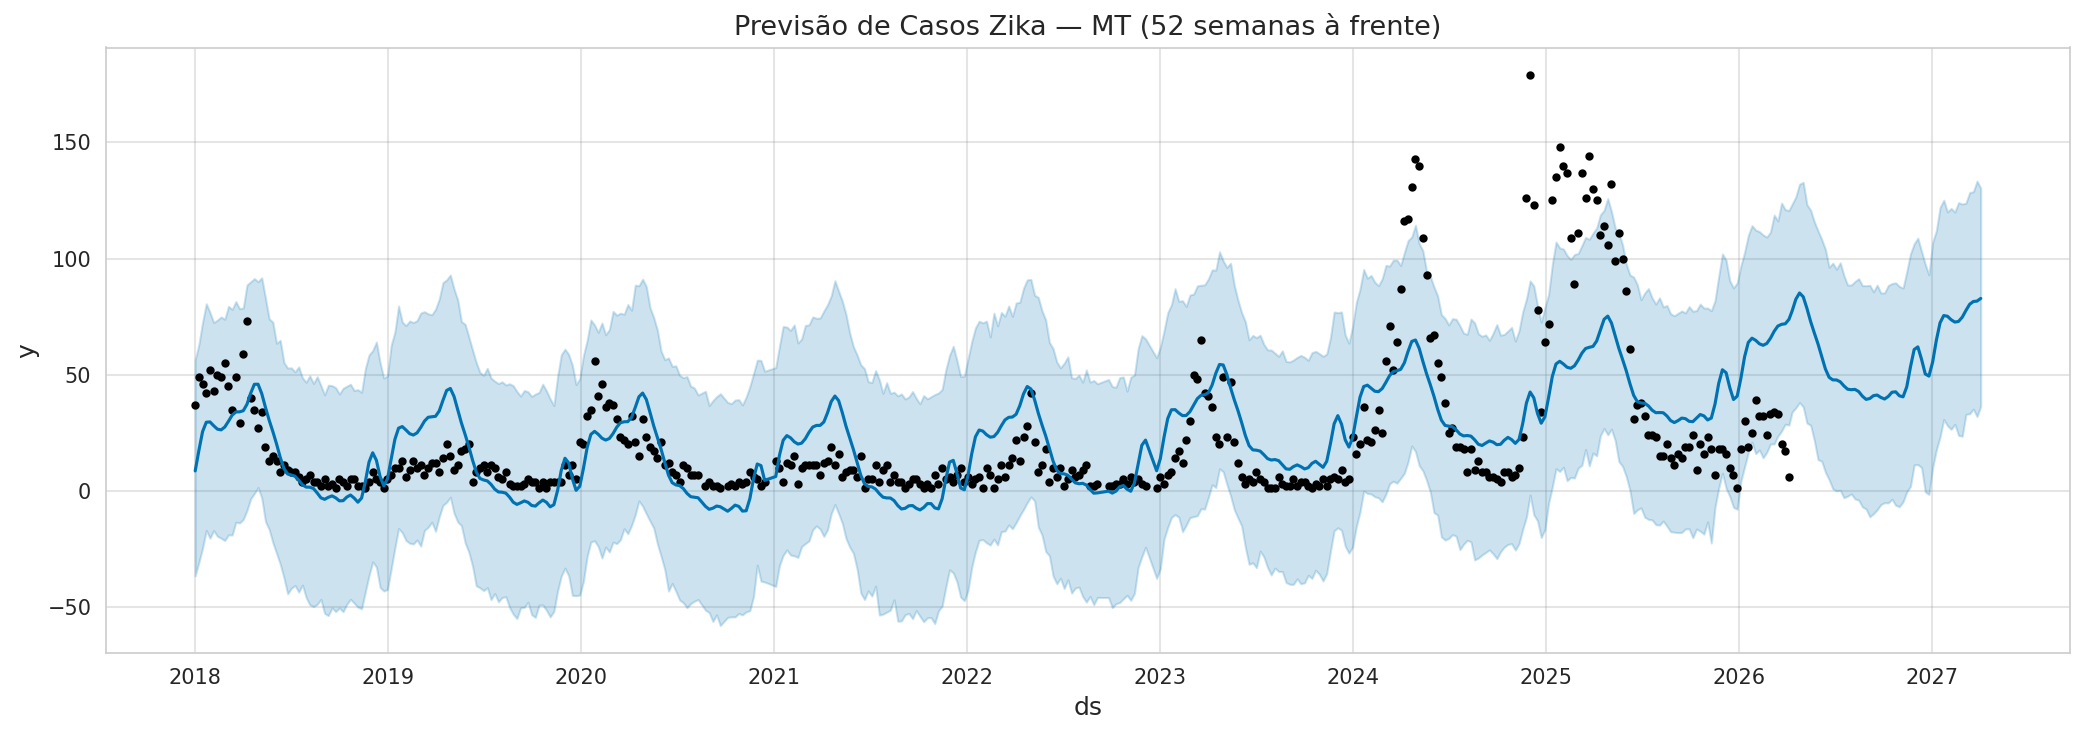

23:17:58 - cmdstanpy - INFO - Chain [1] start processing
23:17:58 - cmdstanpy - INFO - Chain [1] done processing


  Gráfico salvo: prophet_MT.png

Treinando Prophet para: ES


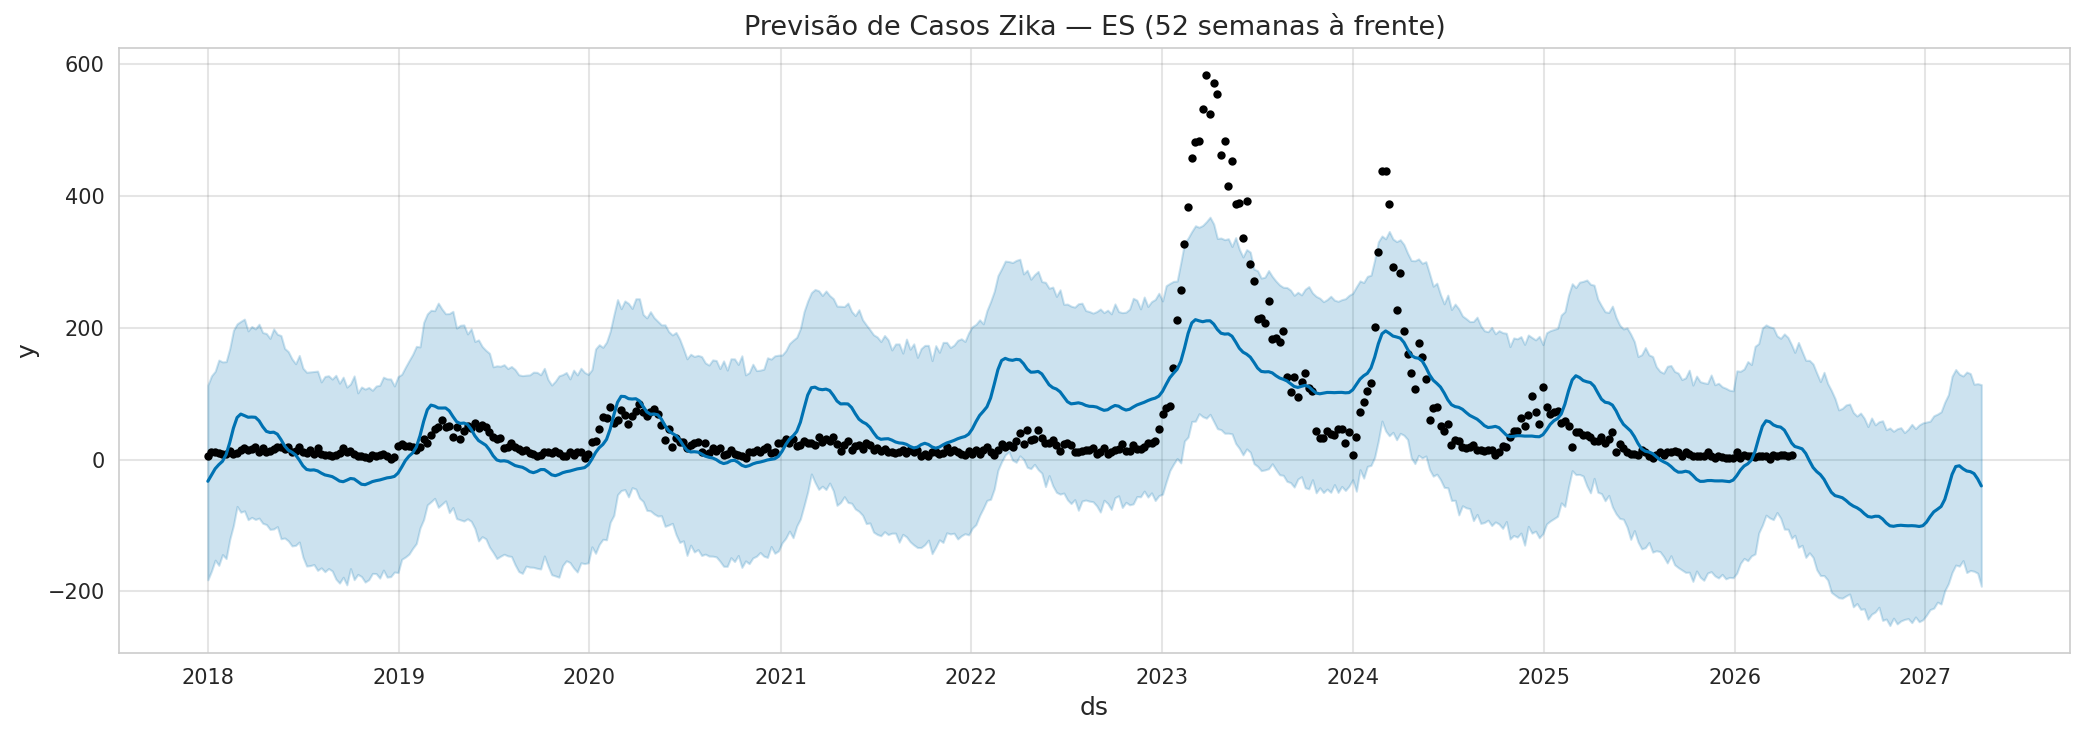

23:17:58 - cmdstanpy - INFO - Chain [1] start processing
23:17:58 - cmdstanpy - INFO - Chain [1] done processing


  Gráfico salvo: prophet_ES.png

Treinando Prophet para: RJ


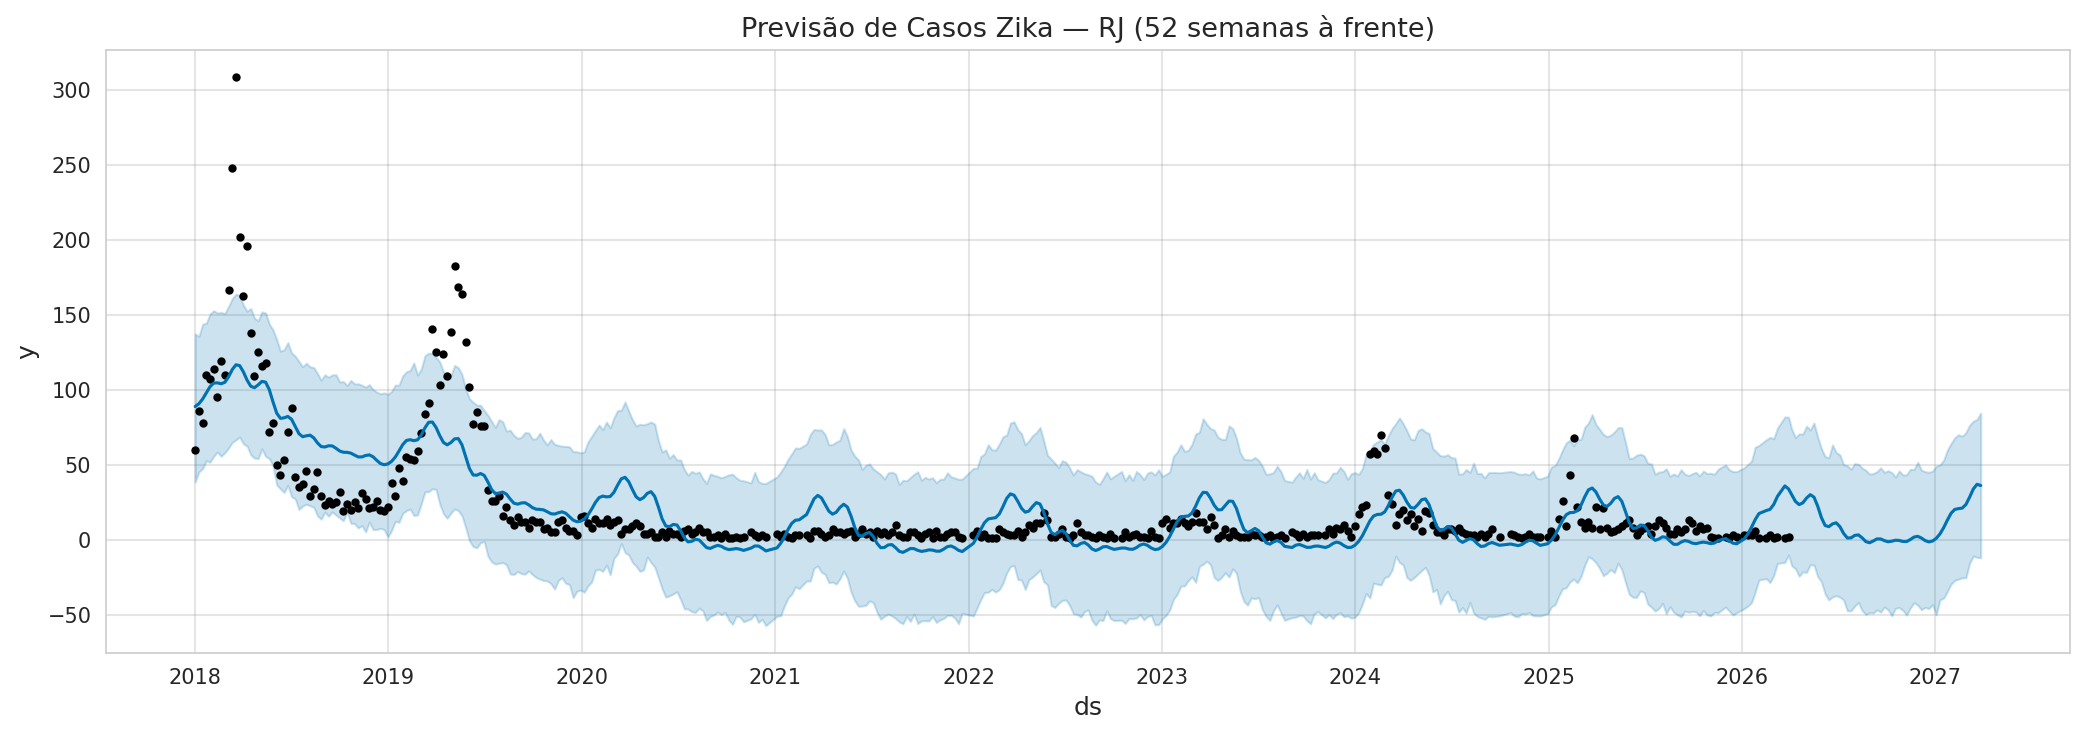

23:17:59 - cmdstanpy - INFO - Chain [1] start processing
23:17:59 - cmdstanpy - INFO - Chain [1] done processing


  Gráfico salvo: prophet_RJ.png

Treinando Prophet para: PB


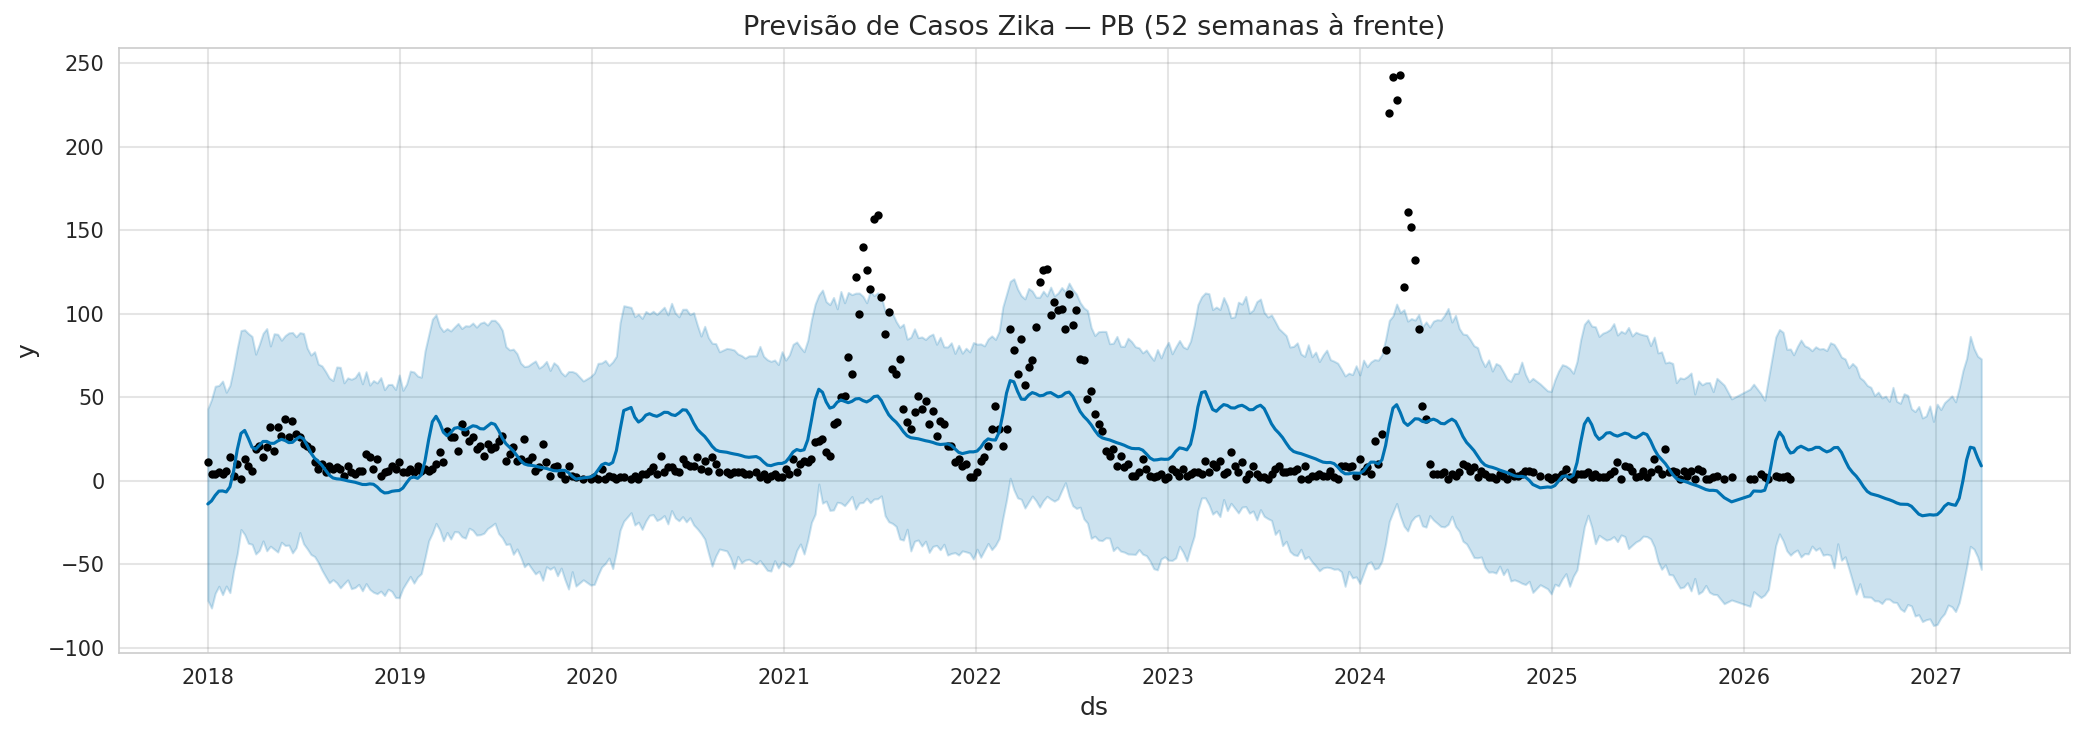

  Gráfico salvo: prophet_PB.png

Prophet finalizado para 5 UFs.


In [122]:
# ── Loop: treina Prophet para cada UF do top 5 ──
resultados_uf = {}

def _semana_iso(row):
    try:
        return datetime.fromisocalendar(int(row['nu_ano']), int(row['sem_pri']), 1)
    except (ValueError, TypeError):
        return pd.NaT

for uf in top5_ufs:
    print(f'\n{"="*50}')
    print(f'Treinando Prophet para: {uf}')
    print(f'{"="*50}')

    subset = df_uf_sem[df_uf_sem['sg_uf'] == uf].copy()
    subset['ds'] = pd.to_datetime(subset.apply(_semana_iso, axis=1))
    subset = subset.dropna(subset=['ds'])
    subset = subset.rename(columns={'total_casos': 'y'})[['ds', 'y']]
    subset = subset.sort_values('ds').reset_index(drop=True)

    if len(subset) < 52:
        print(f'  Dados insuficientes ({len(subset)} semanas). Pulando.')
        continue

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.05,
        interval_width=0.95
    )
    m.fit(subset)

    fut = m.make_future_dataframe(periods=52, freq='W')
    prev = m.predict(fut)
    resultados_uf[uf] = {'modelo': m, 'previsao': prev, 'dados': subset}

    fig = m.plot(prev)
    fig.set_size_inches(14, 5)
    plt.title(f'Previsão de Casos Zika — {uf} (52 semanas à frente)', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'prophet_{uf}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Gráfico salvo: prophet_{uf}.png')

print(f'\nProphet finalizado para {len(resultados_uf)} UFs.')

---
## 🎯 Etapa 4 — Agrupamento de Municípios (K-Means)

Objetivo: agrupar municípios brasileiros por **perfil epidemiológico** semelhante,
 identificando padrões como:
- Municípios de **alta incidência e letalidade**
- Municípios com **possível subnotificação** (muitas notificações, poucos confirmados)
- Municípios de **baixo risco**

Algoritmo: **K-Means** (partitional clustering) com seleção de K via
 Método do Cotovelo + Silhouette Score.

### 4.1 — Feature Engineering por município

In [123]:
SQL_FEATURES = """
SELECT
    g.id_municipio_resi,
    m.nm_municipio,
    u.sg_uf,

    -- Volume
    COUNT(*) AS total_notificacoes,
    COUNT(*) FILTER (WHERE c.classi_fin = 1) AS confirmados,
    COUNT(*) FILTER (WHERE c.evolucao = 2)   AS obitos,

    -- Taxas
    ROUND(COUNT(*) FILTER (WHERE c.classi_fin = 1) * 100.0
          / NULLIF(COUNT(*), 0), 2) AS taxa_confirmacao_pct,
    ROUND(COUNT(*) FILTER (WHERE c.evolucao = 2 AND c.classi_fin = 1) * 100.0
          / NULLIF(COUNT(*) FILTER (WHERE c.classi_fin = 1), 0), 2) AS taxa_letalidade_pct,

    -- Demografia
    ROUND(AVG(p.idade_anos)::numeric, 1) AS media_idade,
    ROUND(COUNT(*) FILTER (WHERE p.cs_sexo = 'F') * 100.0
          / NULLIF(COUNT(*), 0), 2) AS pct_feminino,
    ROUND(COUNT(*) FILTER (WHERE p.cs_gestant IN (1,2,3)) * 100.0
          / NULLIF(COUNT(*), 0), 2) AS pct_gestantes

FROM tb_notificacao n
JOIN tb_dados_clinicos c           ON n.id_notificacao = c.id_notificacao
JOIN tb_paciente p                 ON n.id_paciente = p.id_paciente
JOIN tb_geografia_epidemiologica g ON n.id_notificacao = g.id_notificacao
JOIN tb_municipio m                ON g.id_municipio_resi = m.id_municipio
JOIN tb_uf u                       ON m.id_uf = u.id_uf
GROUP BY g.id_municipio_resi, m.nm_municipio, u.sg_uf
HAVING COUNT(*) >= 10
ORDER BY total_notificacoes DESC;
"""

df_mun = query_df(SQL_FEATURES)

print(f'Municípios com ≥10 notificações: {len(df_mun)}')
print(f'\nEstatísticas descritivas:')
df_mun.describe().round(2)

Municípios com ≥10 notificações: 1527

Estatísticas descritivas:


,id_municipio_resi,total_notificacoes,confirmados,obitos,taxa_confirmacao_pct,taxa_letalidade_pct,media_idade,pct_feminino,pct_gestantes
count,1527.0,1527.00,1527.00,1527.00,1527.00,1143.00,1527.00,1527.00,1527.00
mean,298142.0,146.60,17.59,0.01,16.20,0.16,29.95,64.66,14.09
std,102443.1,403.34,68.16,0.11,23.30,3.35,6.28,13.27,19.33
min,110001.0,10.00,0.00,0.00,0.00,0.00,5.60,10.00,0.00
25%,240395.0,17.00,0.00,0.00,0.00,0.00,26.50,56.25,2.38
50%,291040.0,36.00,3.00,0.00,6.33,0.00,29.90,63.64,6.78
75%,350300.0,107.00,11.00,0.00,20.00,0.00,34.05,71.81,16.67
max,530010.0,5533.00,1674.00,2.00,100.00,100.00,56.70,100.00,100.00


### 4.2 — Pré-processamento e normalização

In [124]:
from sklearn.preprocessing import StandardScaler

# Features numéricas para o modelo
FEATURES = [
    'total_notificacoes', 'confirmados', 'obitos',
    'taxa_confirmacao_pct', 'taxa_letalidade_pct',
    'media_idade', 'pct_feminino', 'pct_gestantes'
]

X = df_mun[FEATURES].fillna(0)

# Normalização (K-Means é sensível à escala)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Shape da matriz de features: {X_scaled.shape}')
print(f'Features: {FEATURES}')

Shape da matriz de features: (1527, 8)
Features: ['total_notificacoes', 'confirmados', 'obitos', 'taxa_confirmacao_pct', 'taxa_letalidade_pct', 'media_idade', 'pct_feminino', 'pct_gestantes']


### 4.3 — Seleção de K: Método do Cotovelo + Silhouette Score

  K= 2 | Inércia=10,152 | Silhouette=0.7930
  K= 3 | Inércia=8,337 | Silhouette=0.3440
  K= 4 | Inércia=7,173 | Silhouette=0.3469
  K= 5 | Inércia=5,881 | Silhouette=0.3562
  K= 6 | Inércia=5,030 | Silhouette=0.3596
  K= 7 | Inércia=4,295 | Silhouette=0.2784
  K= 8 | Inércia=3,875 | Silhouette=0.2797
  K= 9 | Inércia=3,534 | Silhouette=0.2607
  K=10 | Inércia=3,254 | Silhouette=0.2334


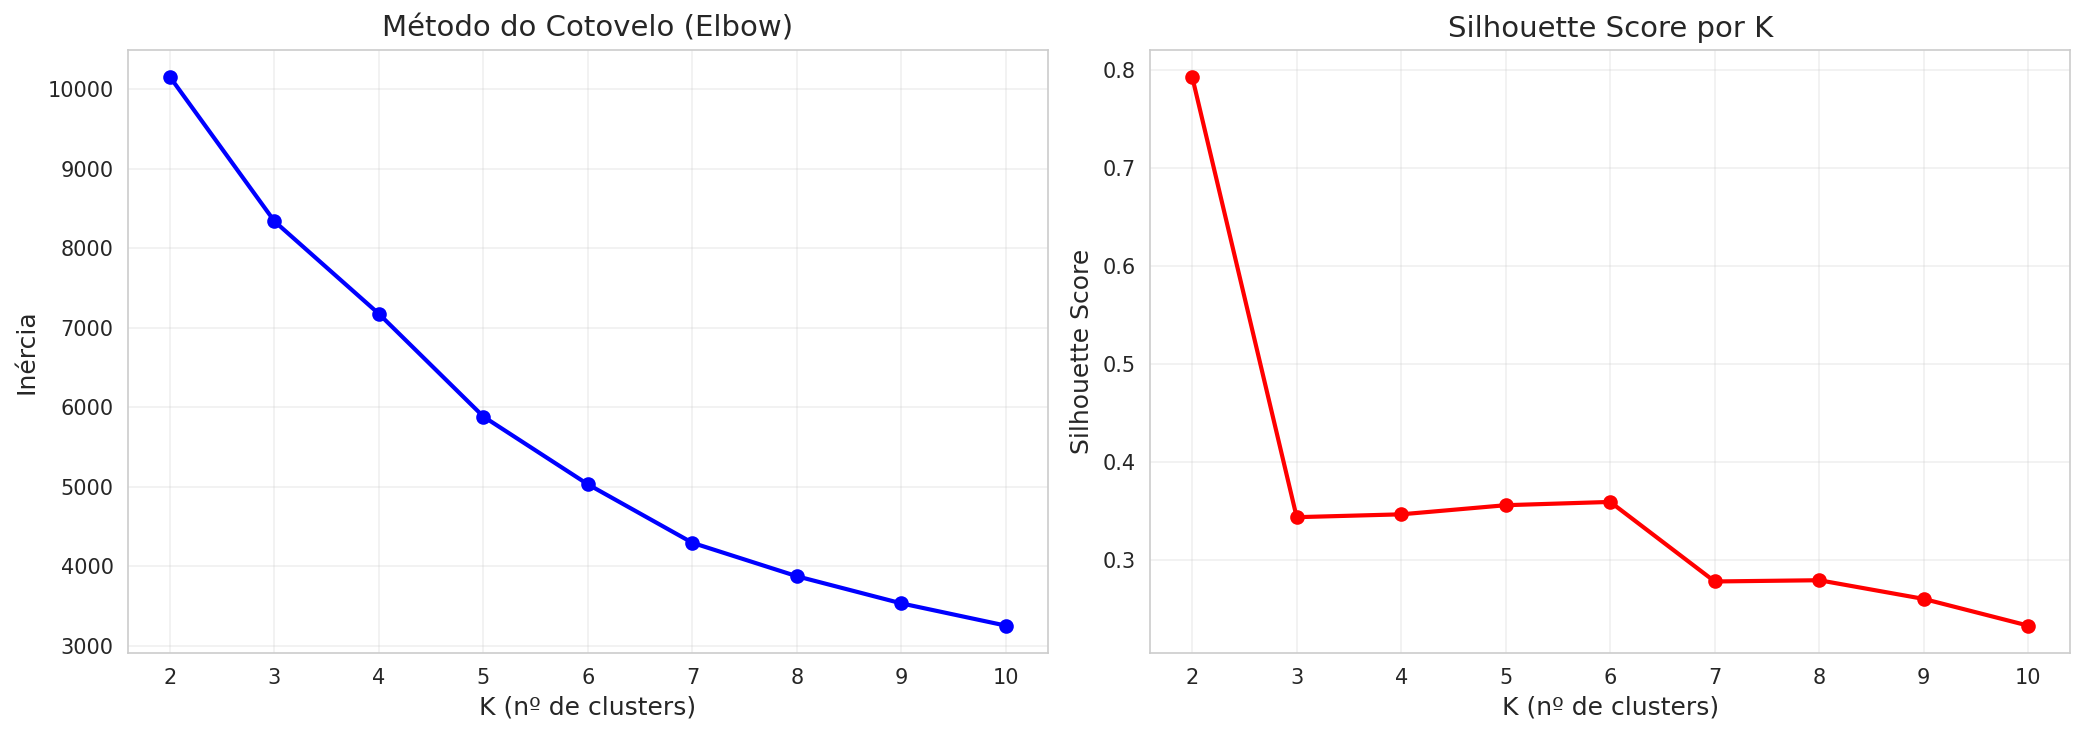


🏆 Melhor K sugerido pelo Silhouette: 2
✅ Gráfico salvo: elbow_silhouette.png


In [125]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))
    print(f'  K={k:2d} | Inércia={km.inertia_:,.0f} | Silhouette={sil_scores[-1]:.4f}')

# ── Gráfico duplo ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-', linewidth=2)
ax1.set_title('Método do Cotovelo (Elbow)')
ax1.set_xlabel('K (nº de clusters)')
ax1.set_ylabel('Inércia')
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, sil_scores, 'ro-', linewidth=2)
ax2.set_title('Silhouette Score por K')
ax2.set_xlabel('K (nº de clusters)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

melhor_k = list(K_range)[np.argmax(sil_scores)]
print(f'\n🏆 Melhor K sugerido pelo Silhouette: {melhor_k}')
print('✅ Gráfico salvo: elbow_silhouette.png')

### 4.4 — Treinamento final e atribuição de clusters

In [126]:
# Treina com o K ideal
km_final = KMeans(n_clusters=melhor_k, random_state=42, n_init=10)
df_mun['cluster'] = km_final.fit_predict(X_scaled)

print(f'Distribuição dos clusters:')
print(df_mun['cluster'].value_counts().sort_index())

Distribuição dos clusters:
cluster
0    1509
1      18
Name: count, dtype: int64


### 4.5 — Perfil médio dos clusters (interpretação)

=== Perfil Médio dos Clusters ===
         total_notificacoes  confirmados  obitos  taxa_confirmacao_pct  taxa_letalidade_pct  media_idade  pct_feminino  pct_gestantes  qtd_municipios
cluster                                                                                                                                              
0                    134.51        14.03     0.0                 16.03                 0.00        29.97         64.66          14.10            1509
1                   1160.39       316.17     1.0                 30.04                10.16        28.21         64.77          12.94              18


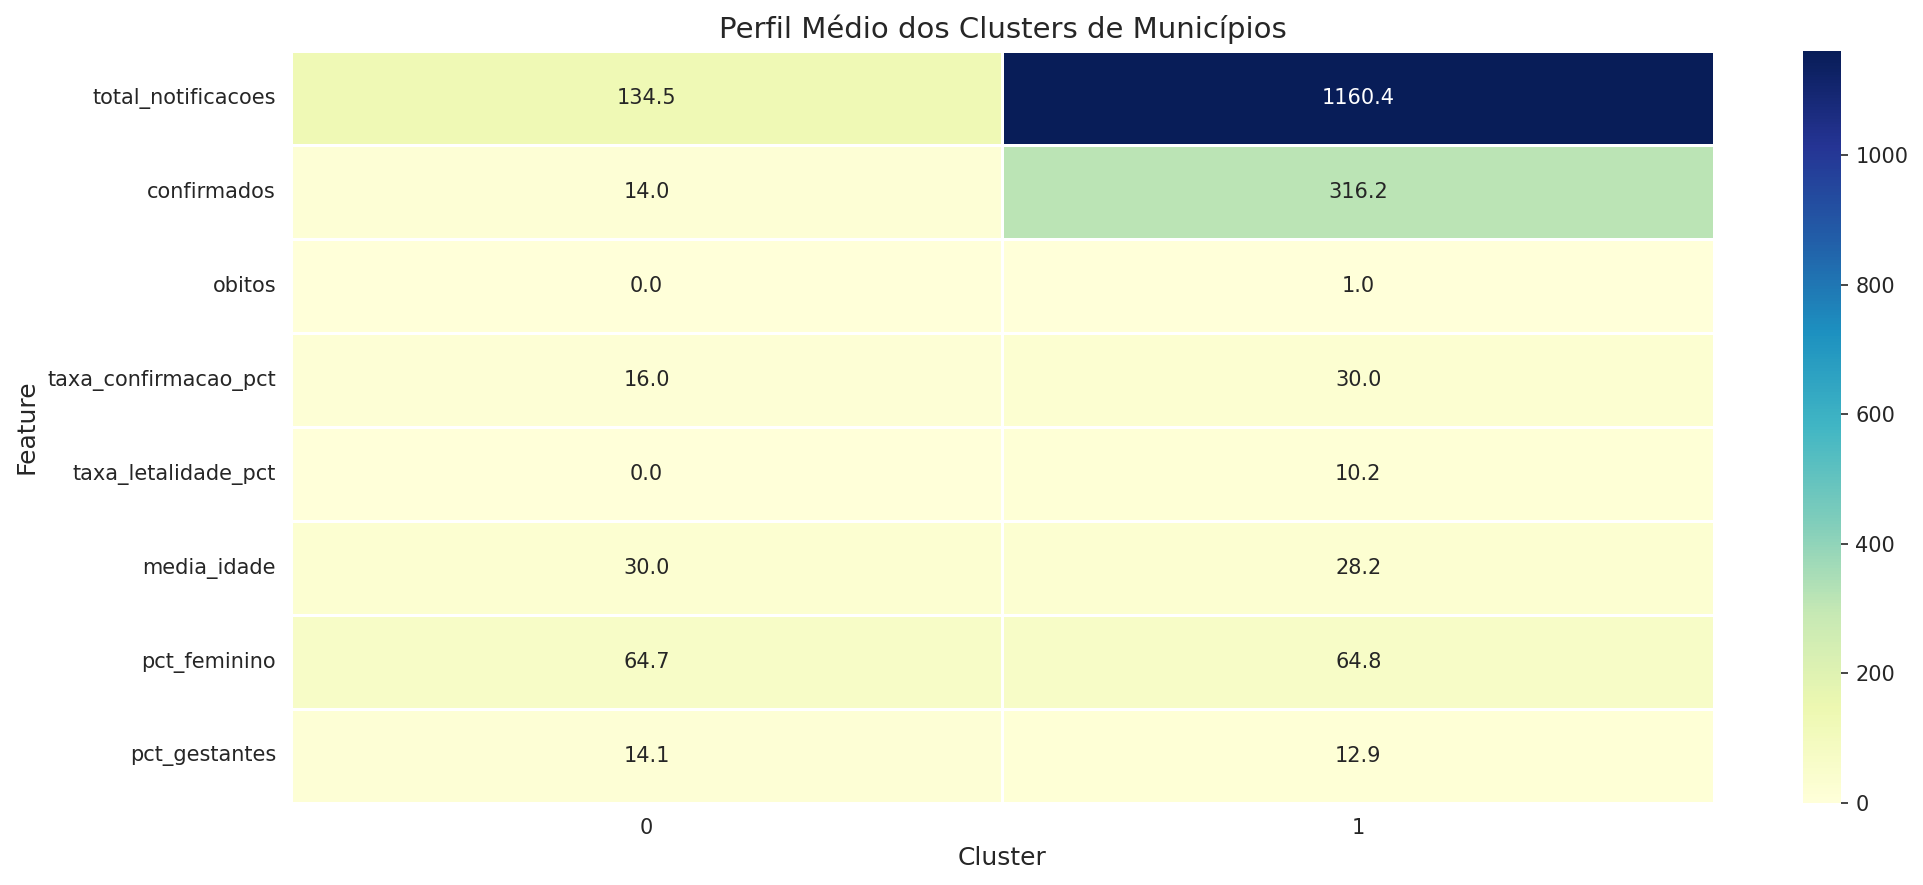

✅ Gráfico salvo: perfil_clusters.png


In [127]:
# ── Tabela de perfil ──
perfil = df_mun.groupby('cluster')[FEATURES].mean().round(2)
perfil['qtd_municipios'] = df_mun.groupby('cluster').size().values

print('=== Perfil Médio dos Clusters ===')
print(perfil.to_string())

# ── Heatmap do perfil ──
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    perfil[FEATURES].T, annot=True, fmt='.1f',
    cmap='YlGnBu', linewidths=0.5, ax=ax
)
ax.set_title('Perfil Médio dos Clusters de Municípios')
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.savefig('perfil_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo: perfil_clusters.png')

### 4.6 — Visualização 2D com PCA

Variância explicada: PC1=24.0% | PC2=21.0%


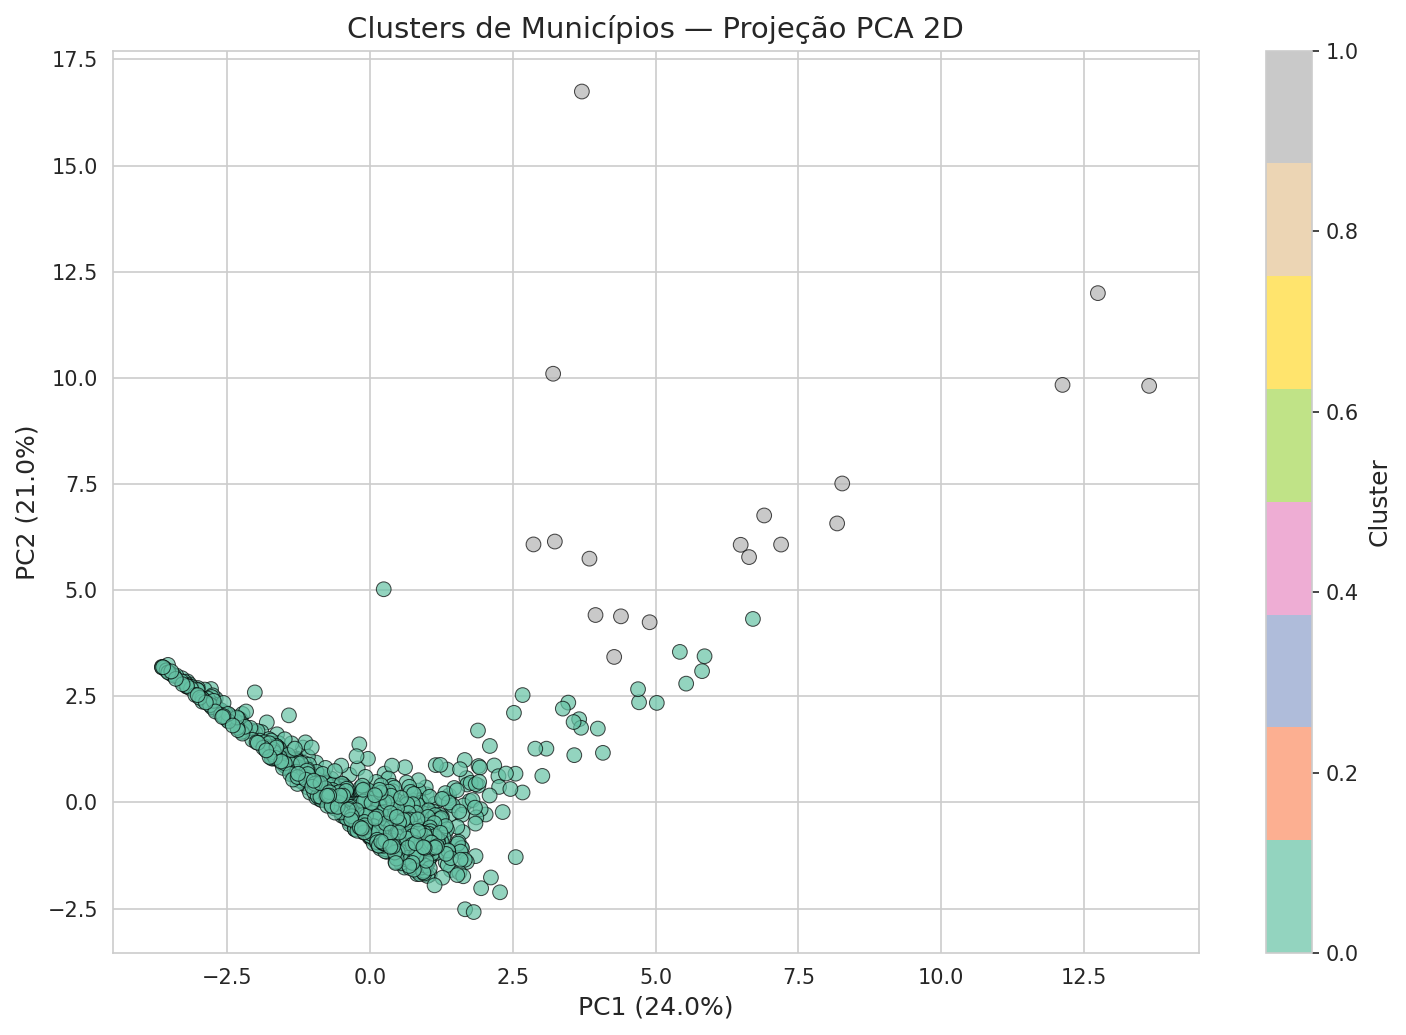

✅ Gráfico salvo: clusters_pca.png


In [128]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_explicada = pca.explained_variance_ratio_
print(f'Variância explicada: PC1={var_explicada[0]*100:.1f}% | PC2={var_explicada[1]*100:.1f}%')

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df_mun['cluster'], cmap='Set2',
    alpha=0.7, edgecolors='k', linewidths=0.5, s=50
)

ax.set_title('Clusters de Municípios — Projeção PCA 2D')
ax.set_xlabel(f'PC1 ({var_explicada[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_explicada[1]*100:.1f}%)')
plt.colorbar(scatter, label='Cluster')

plt.tight_layout()
plt.savefig('clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo: clusters_pca.png')

### 4.7 — Top 10 municípios por cluster

In [129]:
# Exibe os 10 municípios com mais notificações em cada cluster
for c in sorted(df_mun['cluster'].unique()):
    print(f'\n{"="*60}')
    print(f'CLUSTER {c}')
    print(f'{"="*60}')
    top = (df_mun[df_mun['cluster'] == c]
           .nlargest(10, 'total_notificacoes')
           [['nm_municipio', 'sg_uf', 'total_notificacoes',
             'confirmados', 'taxa_confirmacao_pct', 'taxa_letalidade_pct']])
    print(top.to_string(index=False))


CLUSTER 0
    nm_municipio sg_uf  total_notificacoes  confirmados  taxa_confirmacao_pct  taxa_letalidade_pct
Município 260720    PE                5533           49                  0.89                  0.0
Município 172100    TO                4818          119                  2.47                  0.0
Município 320510    ES                4198           50                  1.19                  0.0
Município 320332    ES                3960          185                  4.67                  0.0
Município 530010    DF                3120           94                  3.01                  0.0
Município 261160    PE                3094           82                  2.65                  0.0
Município 293330    BA                3006           96                  3.19                  0.0
Município 521190    GO                2948           88                  2.99                  0.0
Município 110020    RO                2891           84                  2.91                  0.0

---
## 📝 Etapa 5 — Conclusões e Insights Epidemiológicos

Análise de **434 semanas** de notificações de Zika (2018–2026), após limpeza de
qualidade de dados. Resultados obtidos a partir do banco normalizado.

### 1. Sazonalidade
A série apresenta **forte padrão sazonal anual**, confirmado tanto pela decomposição
quanto pelo boxplot mensal. O componente sazonal tem amplitude de cerca de ±450 casos
por semana e se repete de forma consistente todos os anos.

- **Pico:** concentra-se entre **abril e maio** (outono), com a mediana de casos
  semanais mais alta nesses meses (~750–850 casos/semana).
- **Vale:** **setembro a dezembro** registram os menores volumes (~200–250 casos/semana).
- **Observação:** o pico em abril–maio, e não no auge do verão (dez–jan), sugere um
  atraso entre o período chuvoso e a manifestação dos casos — compatível com o ciclo
  de proliferação do *Aedes aegypti* e a latência até a notificação.

### 2. Tendência por UF
- **Top 5 UFs por casos confirmados acumulados:** **BA, MT, ES, RJ e PB**.
- Há divergência entre **volume de notificações** e **casos confirmados**: em 2018,
  o RJ liderou em notificações (3.994), mas com taxa de confirmação baixa; UFs como
  MT apresentaram maior proporção de confirmados, indicando diferenças na capacidade
  diagnóstica e nos critérios de confirmação entre estados.
- A tendência geral (decomposição) mostra **alta até 2019**, **queda acentuada em
  2020–2021** (provável efeito da pandemia de COVID-19 sobre a vigilância e a
  subnotificação de arboviroses), **recuperação a partir de 2022** e novo **pico em
  2024**, seguido de **forte queda** ao final da série.

### 3. Previsão (Prophet)
- O modelo capturou bem o ciclo anual e a tendência. Para as 52 semanas seguintes,
  projeta a **continuidade do padrão sazonal**, com novo pico esperado no
  outono/2027 (`yhat` em torno de 380–415 casos/semana no horizonte final).
- Os **intervalos de confiança são amplos** (chegando a incluir valores negativos no
  limite inferior), refletindo a alta variabilidade entre surtos — anos epidêmicos
  como 2024 são difíceis de prever com precisão.
- A previsão por UF (top 5) foi gerada individualmente, permitindo comparar a
  dinâmica de cada estado.
- *Observação metodológica:* o surto de 2024 aparece como forte anomalia nos resíduos
  da decomposição (resíduos de até +1.300), bem acima do esperado pelo componente
  sazonal — um evento atípico que o modelo trata como ruído, não como padrão.

### 4. Agrupamento de Municípios (K-Means)
O Silhouette Score indicou **K = 2** como a melhor separação (score = 0,79, muito alto),
agrupando 1.527 municípios (com ≥10 notificações) em dois perfis nítidos:

- **Cluster 0 — "perfil comum" (1.509 municípios):** baixo volume (média 135
  notificações), baixa taxa de confirmação (16%) e **letalidade nula**. Representa a
  ampla maioria dos municípios.
- **Cluster 1 — "municípios-foco" (18 municípios):** altíssimo volume (média 1.160
  notificações), maior taxa de confirmação (30%) e **letalidade de 10,2%**. São os
  grandes centros que concentraram a carga da doença.
- *Observação:* a letalidade de 10% no Cluster 1 é elevada para Zika e provavelmente
  reflete **subnotificação de casos leves** nesses municípios (inflando a razão
  óbitos/confirmados), e não uma letalidade biológica real maior. Vale investigação.
- A projeção PCA 2D (PC1 = 24%, PC2 = 21% da variância) confirma visualmente a
  separação dos dois grupos.

### 5. Qualidade de dados (achados metodológicos)
Durante o projeto, foram detectados e tratados diversos problemas da base SINAN —
o que reforça a importância de uma etapa de limpeza rigorosa:

- **5.639 duplicatas** de notificação removidas (2,38%) por chave composta.
- **90 inconsistências clínicas** corrigidas (88 óbitos sem data + 2 curas com óbito).
- **Campo `sem_pri` corrompido** (valores fora de 1–53): contornado derivando a
  semana epidemiológica de `dt_sin_pri`.
- **Datas de sintoma impossíveis** (ex.: ano 1937): filtradas para o intervalo
  válido 2018–2026 (150 semanas-fantasma removidas).
- **Códigos de município inválidos**: tratados na carga das dimensões.

Esses tratamentos garantem que as análises acima reflitam a realidade epidemiológica,
e não artefatos de digitação ou de processamento da base.


---
*Notebook gerado automaticamente para o projeto Zika Vírus — SINAN 2018–2026*  
*Queries alinhadas ao schema: `01_schema.sql` | Views: `03_views.sql`*